# Experiment: 05b Labeled CASALS Point Cloud + H5 Waveform Peak-Ratio Diagnostics

Objective:
- Extend the 05 labeled point-cloud reader by joining CASALS L1B H5 `rx_waveform` diagnostics back to LAS/LAZ points.
- Compute conservative waveform peak features such as `peak_ratio_amp`, `peak_ratio_prominence`, `top12_bin_separation`, and `top1_snr_like`.
- Use these features as diagnostic evidence for noise/ambiguity analysis, not as direct noise labels.
- Check that point-cloud `point_index` / `pulse_index` aligns with the H5 row structure before trusting waveform features.

Scientific boundary:
- The official geolocated point remains the CASALS L1B `refh` point.
- Secondary waveform peaks are diagnostic components only. They are not treated as official georeferenced returns.
- Peak ratio is interpreted as peak dominance / waveform ambiguity, not as a standalone noise probability.


In [1]:
from __future__ import annotations

import json
import re
import time
from collections import defaultdict
from pathlib import Path

import h5py
import ipywidgets as widgets
import laspy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import rasterio
from IPython.display import display
from pyproj import CRS
from scipy.signal import find_peaks, peak_widths
from scipy.spatial import cKDTree

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
plt.style.use("seaborn-v0_8-whitegrid")

PRODUCT_KIND = "transfer_3dep_labels"
# "transfer_3dep_labels", "extract_refh_ground", or "classified_refh"

POINT_CLOUD_NAME = None
# Example transfer: POINT_CLOUD_NAME = "casals_l1b_20241112T165718_001_02.laz"
# Example ground: POINT_CLOUD_NAME = "casals_l1b_20241112T165718_001_02_tentative_ground_idw_filled_snr5_5m_epsg32618_classified_highsnr.las"

DTM_NAME = None
# Example ground: DTM_NAME = "casals_l1b_20241112T165718_001_02_tentative_ground_idw_filled_snr5_5m_epsg32618.tif"

TARGET_CLASSES = None
# Example: TARGET_CLASSES = [1, 2, 7]

DEFAULT_ANALYSIS_CLASSES = [1, 2, 7]
INCLUDE_LOW_OUTLIERS = True

CHUNK_SIZE = 1_000_000
PREVIEW_ROWS = 5
MAX_BOX_PER_GROUP = 50_000
MAX_SCATTER = 100_000
EXPORT_CLASS_CSV = False

ENABLE_LOCAL_NEIGHBOR_FEATURES = True
LOCAL_FEATURE_RADIUS_M = 5.0
LOCAL_FEATURE_MAX_NEIGHBORS = 24
LOCAL_FEATURE_MIN_NEIGHBORS = 6
LOCAL_FEATURE_QUERY_CHUNK_SIZE = 100_000

ENABLE_INTERACTIVE_3D = True
INTERACTIVE_3D_INCLUDE_NOISE = True
MAX_3D_POINTS_TOTAL = 50_000
MAX_3D_POINTS_PER_CLASS = 20_000
EXCLUDE_INVALID_3D_POINTS = True
DEFAULT_3D_AXES_BY_PRODUCT = {
    "extract_refh_ground": ("height_above_ground_m", "roughness_m", "point_density_pts_m3"),
    "transfer_3dep_labels": ("z", "roughness_m", "point_density_pts_m3"),
    "classified_refh": ("height_above_ground_m", "peak_ratio_amp", "point_density_pts_m3"),
}

TRANSFER_OUTPUTS_ROOT = Path("../outputs/transfer_3dep_labels_to_casals")
GROUND_POINT_CLOUD_ROOT = Path("../point_cloud_data/extract_refh_ground")
GROUND_OUTPUTS_ROOT = Path("../outputs/extract_refh_ground")
CLASSIFIED_OUTPUTS_ROOT = Path("../outputs/classify_and_evaluate_casals_refh")
H5_ROOT = Path("../casals_h5_downloads")
H5_NAME = None
# Example: H5_NAME = "casals_l1b_20241112T165718_001_02.h5"
H5_PATH = None
# Optional absolute/relative override. If None, the H5 stem is inferred from the point-cloud product name.

ENABLE_WAVEFORM_PEAK_FEATURES = True
WAVEFORM_FEATURE_SCOPE = "analysis"
# "analysis" uses `analysis_df`; "all_loaded" uses all loaded classes. Use all_loaded when TARGET_CLASSES is restricted intentionally.

WAVEFORM_TARGET_CLASSES = None
# Example: WAVEFORM_TARGET_CLASSES = [1, 2, 7]

MAX_WAVEFORM_POINTS = 200_000
# Set to None to compute features for all selected points. Full-scene extraction can be slow.

WAVEFORM_RANDOM_SEED = 42
WAVEFORM_READ_CHUNK_SIZE = 2048
READ_WAVEFORM_FEATURE_CACHE = True
WRITE_WAVEFORM_FEATURE_CACHE = True
WAVEFORM_FEATURE_OUTPUT_ROOT = Path("../outputs/waveform_peak_ratio_diagnostics")

RX_WAVEFORM_DATASET_CANDIDATES = [
    "rx_waveform",
    "/rx_waveform",
    "rx",
    "rxWaveform",
]
H5_POINT_INDEX_CANDIDATES = ["point_index", "pulse_index"]
H5_REFH_BIN_CANDIDATES = [
    "refh_bin",
    "refh_rx_bin",
    "refh_waveform_bin",
    "refh_bin_index",
    "rx_max_bin",
    "max_rx_bin",
]
H5_VECTOR_FIELD_CANDIDATES = {
    "refh_longitude": ["refh_longitude", "longitude", "lon"],
    "refh_latitude": ["refh_latitude", "latitude", "lat"],
    "refh": ["refh", "refh_height", "height", "elevation"],
    "refh_amp": ["refh_amp", "amp", "amplitude"],
    "refh_snr": ["refh_snr", "snr"],
    "bg_mean": ["bg_mean", "background_mean"],
    "bg_std": ["bg_std", "background_std"],
    "track_num": ["track_num", "track", "track_index"],
    "sweep_num": ["sweep_num", "sweep", "sweep_index"],
}

PEAK_SIGNAL_SOURCE = "background_corrected"
# "background_corrected" subtracts bg_mean when available; otherwise it subtracts the row median.

PEAK_MIN_DISTANCE_BINS = 5
PEAK_MIN_PROMINENCE_SNR = 3.0
PEAK_MIN_HEIGHT_SNR = 3.0
PEAK_MIN_PROMINENCE_ABS = None
PEAK_MIN_HEIGHT_ABS = None
PEAK_WIDTH_REL_HEIGHT = 0.5
PEAK_RATIO_EPS = 1.0e-6
H5_ALIGNMENT_SAMPLE_N = 5000
H5_ALIGNMENT_LONLAT_TOL_DEG = 1.0e-8


DEFAULT_COLUMNS_BY_PRODUCT = {
    "transfer_3dep_labels": [
        "x",
        "y",
        "z",
        "classification",
        "longitude",
        "latitude",
        "x_original_m",
        "y_original_m",
        "z_original_m",
        "empirical_dz_m",
        "quality_flag",
        "ground_align_inlier",
        "refh_amp",
        "refh_snr",
        "bg_mean",
        "bg_std",
        "refh_thres",
        "good_snr",
        "transfer_status",
        "nearest3dep_dist_m",
        "nearest3dep_class",
        "dominant3dep_class",
        "class_vote_ratio",
        "n_3dep_neighbors",
        "track_num",
        "sweep_num",
        "delta_time",
        "refh_error",
        "sphericity",
        "linearity",
        "planarity",
        "anisotropy",
        "omnivariance",
    ],
    "extract_refh_ground": [
        "x",
        "y",
        "z",
        "classification",
        "longitude",
        "latitude",
        "refh_snr",
        "refh_amp",
        "refh_thres",
        "ground_resid",
        "pulse_index",
        "track_num",
        "sweep_num",
        "sphericity",
        "linearity",
        "planarity",
        "anisotropy",
        "omnivariance",
    ],
}

SUMMARY_COLUMNS_BY_PRODUCT = {
    "transfer_3dep_labels": [
        "z",
        "z_original_m",
        "refh_amp",
        "refh_snr",
        "nearest3dep_dist_m",
        "class_vote_ratio",
        "point_density_pts_m3",
        "roughness_m",
        "local_z_span_m",
        "local_z_nmad_m",
        "local_slope_deg",
        "sphericity",
        "linearity",
        "planarity",
        "anisotropy",
        "omnivariance",
    ],
    "extract_refh_ground": [
        "z",
        "refh_amp",
        "refh_snr",
        "ground_resid",
        "local_ground_z_m",
        "height_above_ground_m",
        "point_density_pts_m3",
        "roughness_m",
        "local_z_span_m",
        "local_z_nmad_m",
        "local_slope_deg",
        "sphericity",
        "linearity",
        "planarity",
        "anisotropy",
        "omnivariance",
    ],
}

CLASS_NAME_MAP = {
    1: "unclassified_or_elevated",
    2: "ground",
    7: "low_noise",
    9: "water",
    18: "high_noise",
    20: "ignored",
}

CLASS_COLOR_MAP = {
    1: "#1f77b4",
    2: "#2ca02c",
    7: "#d62728",
    9: "#17becf",
    18: "#9467bd",
    20: "#8c564b",
}


## Plan

- Resolve one explicit product mode and discover the matching LAS/LAZ product.
- Infer or explicitly set the matching H5 file from `casals_h5_downloads`.
- Read selected point-cloud columns, preserving `point_index` or `pulse_index` for H5 row alignment.
- Optionally compute local 3D neighborhood features as in the original 05 notebook.
- Extract waveform peak features from H5 `rx_waveform` for the loaded or sampled points.
- Join waveform features back to the point table and summarize them by class and, when available, pseudo-reference confusion subset.
- Treat waveform features as diagnostic evidence only; no class label is changed in this notebook.


In [2]:
def available_point_clouds(root: Path) -> list[Path]:
    return sorted(list(root.glob("*.las")) + list(root.glob("*.laz")))


def choose_point_cloud(root: Path, point_cloud_name: str | None = None) -> Path:
    clouds = available_point_clouds(root)
    if not clouds:
        raise FileNotFoundError(f"No LAS/LAZ point cloud found under {root.resolve()}")
    if point_cloud_name is None:
        return max(clouds, key=lambda p: p.stat().st_mtime)
    point_cloud_path = root / point_cloud_name
    if not point_cloud_path.exists():
        raise FileNotFoundError(point_cloud_path.resolve())
    return point_cloud_path


def strip_ground_suffix(stem: str) -> str:
    suffix = "_classified_highsnr"
    return stem[:-len(suffix)] if stem.endswith(suffix) else stem


def read_json_if_exists(path: Path | None) -> dict[str, object] | None:
    if path is None or not path.exists():
        return None
    return json.loads(path.read_text(encoding="utf-8"))


def resolve_product_paths(
    product_kind: str,
    point_cloud_name: str | None = None,
    dtm_name: str | None = None,
) -> dict[str, Path | None]:
    if product_kind == "transfer_3dep_labels":
        point_cloud_path = choose_point_cloud(TRANSFER_OUTPUTS_ROOT, point_cloud_name)
        summary_json_path = point_cloud_path.with_name(point_cloud_path.stem + "_summary.json")
        return {
            "point_cloud_path": point_cloud_path,
            "summary_json_path": summary_json_path,
            "dtm_path": None,
            "metadata_json_path": None,
            "export_root": TRANSFER_OUTPUTS_ROOT / "class_tables",
        }

    if product_kind == "extract_refh_ground":
        point_cloud_path = choose_point_cloud(GROUND_POINT_CLOUD_ROOT, point_cloud_name)
        base_stem = strip_ground_suffix(point_cloud_path.stem)
        dtm_path = (GROUND_OUTPUTS_ROOT / dtm_name) if dtm_name else (GROUND_OUTPUTS_ROOT / f"{base_stem}.tif")
        metadata_json_path = GROUND_OUTPUTS_ROOT / f"{base_stem}_metadata.json"
        if not dtm_path.exists():
            raise FileNotFoundError(f"Matching DTM not found: {dtm_path.resolve()}")
        return {
            "point_cloud_path": point_cloud_path,
            "summary_json_path": metadata_json_path if metadata_json_path.exists() else None,
            "dtm_path": dtm_path,
            "metadata_json_path": metadata_json_path if metadata_json_path.exists() else None,
            "export_root": GROUND_OUTPUTS_ROOT / "class_tables",
        }

    raise ValueError(f"Unsupported PRODUCT_KIND: {product_kind}")


def point_cloud_metadata(point_cloud_path: Path) -> dict[str, object]:
    with laspy.open(point_cloud_path) as reader:
        crs_obj = reader.header.parse_crs()
        raw_dims = [dim.name for dim in reader.header.point_format.dimensions]
        columns = ["x", "y", "z"] + [name for name in raw_dims if name not in {"X", "Y", "Z"}]
        extra_columns = list(reader.header.point_format.extra_dimension_names)
        crs_text = crs_obj.to_string() if crs_obj else None
        return {
            "point_count": int(reader.header.point_count),
            "point_format": int(reader.header.point_format.id),
            "crs": crs_text,
            "crs_obj": CRS.from_user_input(crs_text) if crs_text else None,
            "columns": columns,
            "extra_columns": extra_columns,
        }


def existing_columns(available_columns: list[str], requested_columns: list[str]) -> list[str]:
    available = set(available_columns)
    return [col for col in requested_columns if col in available]


def extract_dimension(points: laspy.ScaleAwarePointRecord, name: str) -> np.ndarray:
    if name in {"x", "y", "z"}:
        return np.asarray(getattr(points, name), dtype=np.float64)
    values = getattr(points, name)
    arr = np.asarray(values)
    if arr.dtype.kind == "b":
        return arr.astype(np.uint8)
    return arr


def read_selected_columns_by_class(
    point_cloud_path: Path,
    selected_columns: list[str],
    target_classes: list[int] | None = None,
    chunk_size: int = 1_000_000,
) -> dict[int, pd.DataFrame]:
    data_by_class: dict[int, list[pd.DataFrame]] = defaultdict(list)
    class_filter = None if target_classes is None else {int(v) for v in target_classes}

    with laspy.open(point_cloud_path) as reader:
        for chunk_id, chunk in enumerate(reader.chunk_iterator(chunk_size), start=1):
            cls = np.asarray(chunk.classification, dtype=np.uint8)
            present_classes = np.unique(cls)
            print(f"chunk {chunk_id}: rows={len(cls):,}, classes={present_classes.tolist()}")

            cached_columns = {name: extract_dimension(chunk, name) for name in selected_columns}
            for class_code in present_classes:
                class_code = int(class_code)
                if class_filter is not None and class_code not in class_filter:
                    continue
                mask = cls == class_code
                block = {name: values[mask] for name, values in cached_columns.items()}
                data_by_class[class_code].append(pd.DataFrame(block))

    class_tables: dict[int, pd.DataFrame] = {}
    for class_code, parts in sorted(data_by_class.items()):
        class_tables[class_code] = pd.concat(parts, ignore_index=True)
    return class_tables


def read_dtm_context(dtm_path: Path) -> dict[str, object]:
    with rasterio.open(dtm_path) as src:
        data = src.read(1).astype(np.float64)
        if src.nodata is not None:
            data[np.isclose(data, src.nodata)] = np.nan
        crs_text = src.crs.to_string() if src.crs else None
        return {
            "path": dtm_path,
            "array": data,
            "transform": src.transform,
            "width": src.width,
            "height": src.height,
            "crs": crs_text,
            "crs_obj": CRS.from_user_input(src.crs.to_wkt()) if src.crs else None,
        }


def assert_matching_crs(point_cloud_crs: CRS | None, dtm_crs: CRS | None) -> None:
    if point_cloud_crs is None:
        raise ValueError("Point-cloud CRS is missing; cannot sample DTM safely.")
    if dtm_crs is None:
        raise ValueError("DTM CRS is missing; cannot sample DTM safely.")
    if not point_cloud_crs.equals(dtm_crs):
        raise ValueError(
            "Point-cloud CRS and DTM CRS do not match. "
            f"LAS CRS: {point_cloud_crs.to_string()} | DTM CRS: {dtm_crs.to_string()}"
        )


def finite_mask(*arrays: np.ndarray) -> np.ndarray:
    if not arrays:
        raise ValueError("finite_mask requires at least one array")
    mask = np.ones(np.asarray(arrays[0]).shape[0], dtype=bool)
    for arr in arrays:
        mask &= np.isfinite(np.asarray(arr))
    return mask


def robust_nmad(values: np.ndarray) -> float:
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return float("nan")
    median = np.median(values)
    return float(1.4826 * np.median(np.abs(values - median)))


def sample_dtm_bilinear(dtm_context: dict[str, object], x: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    arr = np.asarray(dtm_context["array"], dtype=np.float64)
    transform = dtm_context["transform"]
    width = int(dtm_context["width"])
    height = int(dtm_context["height"])

    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    col_f, row_f = (~transform) * (x, y)
    u = np.asarray(col_f, dtype=np.float64) - 0.5
    v = np.asarray(row_f, dtype=np.float64) - 0.5

    col0 = np.floor(u).astype(np.int64)
    row0 = np.floor(v).astype(np.int64)
    dc = u - col0
    dr = v - row0

    in_bounds = (col0 >= 0) & (row0 >= 0) & (col0 + 1 < width) & (row0 + 1 < height)
    samples = np.full(x.shape[0], np.nan, dtype=np.float64)
    valid = np.zeros(x.shape[0], dtype=bool)

    idx = np.flatnonzero(in_bounds)
    if idx.size == 0:
        return samples, valid

    r0 = row0[idx]
    c0 = col0[idx]
    r1 = r0 + 1
    c1 = c0 + 1

    q00 = arr[r0, c0]
    q10 = arr[r0, c1]
    q01 = arr[r1, c0]
    q11 = arr[r1, c1]
    finite_neighbors = np.isfinite(q00) & np.isfinite(q10) & np.isfinite(q01) & np.isfinite(q11)

    if not np.any(finite_neighbors):
        return samples, valid

    idx = idx[finite_neighbors]
    r0 = row0[idx]
    c0 = col0[idx]
    r1 = r0 + 1
    c1 = c0 + 1
    t = dc[idx]
    s = dr[idx]

    q00 = arr[r0, c0]
    q10 = arr[r0, c1]
    q01 = arr[r1, c0]
    q11 = arr[r1, c1]
    samples[idx] = (
        (1.0 - t) * (1.0 - s) * q00
        + t * (1.0 - s) * q10
        + (1.0 - t) * s * q01
        + t * s * q11
    )
    valid[idx] = True
    return samples, valid


def attach_ground_metrics_to_class_tables(
    class_tables: dict[int, pd.DataFrame],
    dtm_context: dict[str, object],
) -> dict[int, pd.DataFrame]:
    out: dict[int, pd.DataFrame] = {}
    for class_code, df in class_tables.items():
        df2 = df.copy()
        local_ground_z_m, dtm_sample_valid = sample_dtm_bilinear(
            dtm_context,
            df2["x"].to_numpy(dtype=np.float64),
            df2["y"].to_numpy(dtype=np.float64),
        )
        df2["local_ground_z_m"] = local_ground_z_m
        df2["dtm_sample_valid"] = dtm_sample_valid.astype(np.uint8)
        df2["height_above_ground_m"] = df2["z"].to_numpy(dtype=np.float64) - local_ground_z_m
        out[class_code] = df2
    return out



def compute_local_neighbor_features(
    df: pd.DataFrame,
    radius_m: float,
    max_neighbors: int,
    min_neighbors: int,
    query_chunk_size: int,
) -> pd.DataFrame:
    feature_names = [
        "local_neighbor_count",
        "point_density_pts_m3",
        "roughness_m",
        "local_z_span_m",
        "local_z_nmad_m",
        "local_slope_deg",
        "sphericity",
        "linearity",
        "planarity",
        "anisotropy",
        "omnivariance",
    ]
    out = {name: np.full(len(df), np.nan, dtype=np.float64) for name in feature_names}
    if df.empty:
        return pd.DataFrame(out, index=df.index)
    if any(col not in df.columns for col in ["x", "y", "z"]):
        return pd.DataFrame(out, index=df.index)

    xyz = np.column_stack(
        [
            pd.to_numeric(df["x"], errors="coerce").to_numpy(dtype=np.float64),
            pd.to_numeric(df["y"], errors="coerce").to_numpy(dtype=np.float64),
            pd.to_numeric(df["z"], errors="coerce").to_numpy(dtype=np.float64),
        ]
    )
    valid_xyz = finite_mask(xyz[:, 0], xyz[:, 1], xyz[:, 2])
    if not np.any(valid_xyz):
        return pd.DataFrame(out, index=df.index)

    xyz_valid = xyz[valid_xyz]
    tree = cKDTree(xyz_valid)
    valid_indices = np.flatnonzero(valid_xyz)
    sphere_volume_m3 = float((4.0 / 3.0) * np.pi * float(radius_m) ** 3)

    max_neighbors = max(int(max_neighbors), int(min_neighbors), 1)
    query_chunk_size = max(1, int(query_chunk_size))

    for start in range(0, xyz_valid.shape[0], query_chunk_size):
        end = min(start + query_chunk_size, xyz_valid.shape[0])
        query_xyz = xyz_valid[start:end]
        print(f"local_feature_chunk: {end:,}/{xyz_valid.shape[0]:,}")
        try:
            neighbor_count = np.asarray(
                tree.query_ball_point(query_xyz, r=float(radius_m), return_length=True, workers=-1),
                dtype=np.int32,
            )
        except TypeError:
            neighbor_count = np.asarray(
                [len(ids) for ids in tree.query_ball_point(query_xyz, r=float(radius_m), workers=-1)],
                dtype=np.int32,
            )

        distances, neighbor_idx = tree.query(
            query_xyz,
            k=int(max_neighbors),
            distance_upper_bound=float(radius_m),
            workers=-1,
        )
        if int(max_neighbors) == 1:
            distances = distances[:, None]
            neighbor_idx = neighbor_idx[:, None]
        valid_neighbor_mask = np.isfinite(distances) & (neighbor_idx >= 0) & (neighbor_idx < xyz_valid.shape[0])

        for local_idx in range(query_xyz.shape[0]):
            target_idx = valid_indices[start + local_idx]
            count = int(neighbor_count[local_idx])
            out["local_neighbor_count"][target_idx] = float(count)
            out["point_density_pts_m3"][target_idx] = count / sphere_volume_m3 if sphere_volume_m3 > 0 else np.nan

            if count < int(min_neighbors):
                continue

            neighbor_ids = neighbor_idx[local_idx, valid_neighbor_mask[local_idx]]
            neighborhood_xyz = xyz_valid[neighbor_ids]
            if neighborhood_xyz.shape[0] < int(min_neighbors):
                continue

            neighborhood_z = neighborhood_xyz[:, 2]
            out["local_z_span_m"][target_idx] = float(np.nanmax(neighborhood_z) - np.nanmin(neighborhood_z))
            out["local_z_nmad_m"][target_idx] = robust_nmad(neighborhood_z)

            centroid = neighborhood_xyz.mean(axis=0)
            centered = neighborhood_xyz - centroid
            try:
                eigvals, eigvecs = np.linalg.eigh((centered.T @ centered) / float(neighborhood_xyz.shape[0]))
            except np.linalg.LinAlgError:
                continue

            eigvals = np.clip(np.asarray(eigvals, dtype=np.float64), 0.0, None)
            l1, l2, l3 = eigvals[::-1]
            if not np.isfinite(l1) or l1 <= 0:
                continue

            out["sphericity"][target_idx] = float(l3 / l1)
            out["linearity"][target_idx] = float((l1 - l2) / l1)
            out["planarity"][target_idx] = float((l2 - l3) / l1)
            out["anisotropy"][target_idx] = float((l1 - l3) / l1)
            out["omnivariance"][target_idx] = float(np.cbrt(max(l1 * l2 * l3, 0.0)))

            normal = eigvecs[:, int(np.argmin(eigvals))]
            normal_norm = float(np.linalg.norm(normal))
            if not np.isfinite(normal_norm) or normal_norm <= 0:
                continue
            normal = normal / normal_norm

            center_xyz = query_xyz[local_idx]
            out["roughness_m"][target_idx] = float(abs((center_xyz - centroid) @ normal))
            out["local_slope_deg"][target_idx] = float(
                np.degrees(np.arctan2(np.linalg.norm(normal[:2]), abs(normal[2])))
            )

    return pd.DataFrame(out, index=df.index)


def attach_local_neighbor_features_to_class_tables(
    class_tables: dict[int, pd.DataFrame],
    radius_m: float,
    max_neighbors: int,
    min_neighbors: int,
    query_chunk_size: int,
) -> dict[int, pd.DataFrame]:
    if not class_tables:
        return {}

    combined = combine_class_tables(class_tables)
    feature_df = compute_local_neighbor_features(
        combined,
        radius_m=radius_m,
        max_neighbors=max_neighbors,
        min_neighbors=min_neighbors,
        query_chunk_size=query_chunk_size,
    )
    combined = combined.copy()
    for col in feature_df.columns:
        combined[col] = feature_df[col].to_numpy()

    out: dict[int, pd.DataFrame] = {}
    start = 0
    for class_code in sorted(class_tables):
        n_rows = len(class_tables[class_code])
        out[class_code] = combined.iloc[start : start + n_rows].reset_index(drop=True)
        start += n_rows
    return out


def resolve_analysis_class_codes(
    class_tables: dict[int, pd.DataFrame],
    default_analysis_classes: list[int],
    include_low_outliers: bool,
) -> list[int]:
    codes = [int(code) for code in default_analysis_classes if int(code) in class_tables]
    if include_low_outliers and 7 in class_tables and 7 not in codes:
        codes.append(7)
    if not codes:
        codes = sorted(class_tables)
    return codes


def combine_class_tables(class_tables: dict[int, pd.DataFrame]) -> pd.DataFrame:
    if not class_tables:
        return pd.DataFrame()
    return pd.concat([class_tables[class_code] for class_code in sorted(class_tables)], ignore_index=True)


def sample_per_group(df: pd.DataFrame, group_col: str, max_n: int) -> pd.DataFrame:
    parts = []
    for _, group in df.groupby(group_col, sort=False, observed=False):
        parts.append(group.sample(n=min(len(group), max_n), random_state=42))
    if not parts:
        return df.iloc[0:0].copy()
    return pd.concat(parts, ignore_index=True)


def summarize_class_tables(class_tables: dict[int, pd.DataFrame], stat_columns: list[str]) -> pd.DataFrame:
    rows = []
    for class_code, df in class_tables.items():
        row = {
            "classification": int(class_code),
            "class_name": CLASS_NAME_MAP.get(int(class_code), f"class_{int(class_code)}"),
            "n_points": int(len(df)),
        }
        if "dtm_sample_valid" in df.columns:
            row["dtm_sample_valid_fraction"] = float(pd.to_numeric(df["dtm_sample_valid"], errors="coerce").fillna(0).mean())
        for col in stat_columns:
            if col not in df.columns:
                continue
            values = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan)
            row[f"{col}_mean"] = float(values.mean()) if values.notna().any() else np.nan
            row[f"{col}_median"] = float(values.median()) if values.notna().any() else np.nan
            row[f"{col}_p95"] = float(values.quantile(0.95)) if values.notna().any() else np.nan
        rows.append(row)
    if not rows:
        return pd.DataFrame(columns=["classification", "class_name", "n_points"])
    return pd.DataFrame(rows).sort_values(["n_points", "classification"], ascending=[False, True]).reset_index(drop=True)


def summary_metrics_table(product_kind: str, summary_payload: dict[str, object] | None) -> pd.DataFrame | None:
    if summary_payload is None:
        return None
    if product_kind == "transfer_3dep_labels":
        return pd.DataFrame(
            {
                "metric": ["casals_points", "dep3_points", "dz_m_added_to_casals"],
                "value": [
                    summary_payload["counts"]["casals_points"],
                    summary_payload["counts"]["dep3_points"],
                    summary_payload["alignment"]["dz_m_added_to_casals"],
                ],
            }
        )
    return pd.DataFrame(
        {
            "metric": ["n_total_records", "n_high_snr", "n_ground_candidates", "valid_dtm_cells"],
            "value": [
                summary_payload["counts"]["n_total_records"],
                summary_payload["counts"]["n_high_snr"],
                summary_payload["counts"]["n_ground_candidates"],
                summary_payload["final_grid"]["valid_dtm_cells"],
            ],
        }
    )


def export_class_tables(class_tables: dict[int, pd.DataFrame], export_root: Path) -> dict[int, Path]:
    export_root.mkdir(parents=True, exist_ok=True)
    exported: dict[int, Path] = {}
    for class_code, df in class_tables.items():
        out_path = export_root / f"class_{class_code}.csv"
        df.to_csv(out_path, index=False)
        exported[class_code] = out_path
    return exported


def get_numeric_axis_candidates(df: pd.DataFrame) -> list[str]:
    if df.empty:
        return []
    cols = []
    for col in df.columns:
        series = pd.to_numeric(df[col], errors="coerce") if df[col].dtype == object else df[col]
        if pd.api.types.is_numeric_dtype(series) and pd.to_numeric(series, errors="coerce").notna().any():
            cols.append(col)
    return cols


def choose_axis_field(preferred: str, available_columns: list[str], used_columns: set[str]) -> str:
    fallback_order = [preferred, "z", "roughness_m", "point_density_pts_m3", "refh_snr", "refh_amp"] + list(available_columns)
    for col in fallback_order:
        if col in available_columns and col not in used_columns:
            return col
    for col in fallback_order:
        if col in available_columns:
            return col
    raise ValueError("No numeric columns are available for 3D axis selection.")


def resolve_default_3d_axes(product_kind: str, numeric_columns: list[str]) -> tuple[str, str, str]:
    preferred_axes = DEFAULT_3D_AXES_BY_PRODUCT.get(product_kind, ("z", "roughness_m", "point_density_pts_m3"))
    used: set[str] = set()
    axes = []
    for preferred in preferred_axes:
        axis_col = choose_axis_field(preferred, numeric_columns, used)
        axes.append(axis_col)
        used.add(axis_col)
    return tuple(axes)


def get_hover_columns(df: pd.DataFrame, axis_fields: tuple[str, str, str]) -> list[str]:
    curated = [
        "refh_snr",
        "refh_amp",
        "height_above_ground_m",
        "point_density_pts_m3",
        "roughness_m",
        "local_z_span_m",
        "local_z_nmad_m",
        "local_slope_deg",
        "sphericity",
        "linearity",
        "planarity",
        "anisotropy",
        "omnivariance",
        "local_neighbor_count",
        "ground_resid",
        "z",
        "track_num",
        "sweep_num",
    ]
    out = []
    for col in curated:
        if col in df.columns and col not in axis_fields and col not in out:
            out.append(col)
    return out


def class_color_lookup(class_codes: list[int]) -> dict[int, str]:
    palette = px.colors.qualitative.Bold + px.colors.qualitative.Safe + px.colors.qualitative.Set2
    out = dict(CLASS_COLOR_MAP)
    palette_idx = 0
    for class_code in sorted({int(v) for v in class_codes}):
        if class_code in out:
            continue
        out[class_code] = palette[palette_idx % len(palette)]
        palette_idx += 1
    return out


def prepare_interactive_3d_frame(
    df: pd.DataFrame,
    x_axis: str,
    y_axis: str,
    z_axis: str,
    product_kind: str,
    exclude_invalid_3d_points: bool,
) -> pd.DataFrame:
    required = [x_axis, y_axis, z_axis, "classification"]
    for col in required:
        if col not in df.columns:
            return df.iloc[0:0].copy()

    out = df.copy()
    if (
        product_kind == "extract_refh_ground"
        and exclude_invalid_3d_points
        and "dtm_sample_valid" in out.columns
        and "height_above_ground_m" in {x_axis, y_axis, z_axis}
    ):
        out = out.loc[pd.to_numeric(out["dtm_sample_valid"], errors="coerce").fillna(0).astype(bool)].copy()

    for axis_col in [x_axis, y_axis, z_axis]:
        out[axis_col] = pd.to_numeric(out[axis_col], errors="coerce")
    out = out.replace([np.inf, -np.inf], np.nan)
    out = out.dropna(subset=[x_axis, y_axis, z_axis]).copy()
    out["classification"] = pd.to_numeric(out["classification"], errors="coerce").astype(int)
    out["class_name"] = out["classification"].map(lambda x: CLASS_NAME_MAP.get(int(x), f"class_{int(x)}"))
    out["class_label"] = out["classification"].map(lambda x: f"{int(x)} ({CLASS_NAME_MAP.get(int(x), f'class_{int(x)}')})")
    return out


def stratified_sample_for_3d(
    df: pd.DataFrame,
    max_points_per_class: int,
    max_points_total: int,
) -> pd.DataFrame:
    if df.empty:
        return df.copy()

    sampled_parts = []
    for _, group in df.groupby("classification", sort=True, observed=False):
        n = min(len(group), int(max_points_per_class))
        sampled_parts.append(group.sample(n=n, random_state=42) if len(group) > n else group.copy())
    sampled = pd.concat(sampled_parts, ignore_index=True)

    if len(sampled) <= int(max_points_total):
        return sampled

    class_counts = sampled["classification"].value_counts().sort_index()
    ideal = class_counts / class_counts.sum() * int(max_points_total)
    alloc = np.floor(ideal).astype(int)
    alloc[alloc < 1] = 1

    while alloc.sum() > int(max_points_total):
        reducible = alloc[alloc > 1]
        if reducible.empty:
            break
        alloc.loc[reducible.idxmax()] -= 1

    remainder = int(max_points_total) - int(alloc.sum())
    fractions = (ideal - np.floor(ideal)).sort_values(ascending=False)
    for class_code in fractions.index:
        if remainder <= 0:
            break
        if alloc.loc[class_code] < class_counts.loc[class_code]:
            alloc.loc[class_code] += 1
            remainder -= 1

    downsampled_parts = []
    for class_code, group in sampled.groupby("classification", sort=True, observed=False):
        n = min(len(group), int(alloc.loc[class_code]))
        downsampled_parts.append(group.sample(n=n, random_state=42) if len(group) > n else group.copy())
    return pd.concat(downsampled_parts, ignore_index=True)


def make_interactive_3d_figure(
    df: pd.DataFrame,
    x_axis: str,
    y_axis: str,
    z_axis: str,
    hover_columns: list[str],
    class_colors: dict[int, str],
) -> go.Figure:
    fig = go.Figure()
    if df.empty:
        fig.add_annotation(text="No points are available for the selected axes.", x=0.5, y=0.5, showarrow=False)
        fig.update_layout(width=1000, height=650)
        return fig

    marker_size = 3 if len(df) <= 15_000 else 2
    marker_opacity = 0.65 if len(df) <= 15_000 else 0.45

    for class_code, group in df.groupby("classification", sort=True, observed=False):
        class_code = int(class_code)
        hover_cols = [col for col in hover_columns if col in group.columns]
        customdata = group[hover_cols].to_numpy() if hover_cols else None
        hover_lines = [
            f"class={class_code} ({CLASS_NAME_MAP.get(class_code, f'class_{class_code}')})",
            f"{x_axis}=%{{x:.3f}}",
            f"{y_axis}=%{{y:.3f}}",
            f"{z_axis}=%{{z:.3f}}",
        ]
        for idx, col in enumerate(hover_cols):
            hover_lines.append(f"{col}=%{{customdata[{idx}]:.3f}}")
        hovertemplate = "<br>".join(hover_lines) + "<extra></extra>"

        fig.add_trace(
            go.Scatter3d(
                x=group[x_axis],
                y=group[y_axis],
                z=group[z_axis],
                mode="markers",
                name=f"{class_code} ({CLASS_NAME_MAP.get(class_code, f'class_{class_code}')})",
                marker={
                    "size": marker_size,
                    "opacity": marker_opacity,
                    "color": class_colors.get(class_code, "#7f7f7f"),
                },
                customdata=customdata,
                hovertemplate=hovertemplate,
            )
        )

    fig.update_layout(
        width=1000,
        height=700,
        template="plotly_white",
        legend={"title": "classification"},
        margin={"l": 0, "r": 0, "t": 40, "b": 0},
        scene={
            "xaxis": {"title": x_axis, "autorange": True},
            "yaxis": {"title": y_axis, "autorange": True},
            "zaxis": {"title": z_axis, "autorange": True},
            "aspectmode": "cube",
        },
        title=f"Interactive 3D feature view: {x_axis} vs {y_axis} vs {z_axis}",
    )
    return fig


In [3]:

# --------------------------------------------------------------------------------------
# H5 waveform extension helpers
# --------------------------------------------------------------------------------------

WAVEFORM_FEATURE_COLUMNS = [
    "waveform_feature_available",
    "n_detected_peaks",
    "raw_max_bin",
    "raw_max_amp",
    "top1_bin",
    "top2_bin",
    "top1_amp",
    "top2_amp",
    "top1_amp_bgcorr",
    "top2_amp_bgcorr",
    "peak_ratio_amp",
    "peak_ratio_amp_bgcorr",
    "top1_prominence",
    "top2_prominence",
    "peak_ratio_prominence",
    "top1_width_bins",
    "top2_width_bins",
    "top12_bin_separation",
    "top1_snr_like",
    "top2_snr_like",
    "refh_bin",
    "refh_to_top1_bin_delta",
    "refh_peak_rank",
    "official_refh_amp_to_top1_amp_ratio",
    "official_refh_amp_to_top1_bgcorr_ratio",
]

# Preserve point-to-H5 alignment columns whenever they exist in LAS/LAZ.
for product_name, columns in DEFAULT_COLUMNS_BY_PRODUCT.items():
    for extra_col in [
        "point_index",
        "pulse_index",
        "eval_gt_class",
        "eval_match_valid",
        "pred_class_baseline",
        "classification_reason",
        "height_above_ground_m",
        "local_ground_z_m",
        "dtm_sample_valid",
        "point_density_pts_m3",
        "nearest_ground_cell_dist_m",
        "track_hag_robust_z",
        "sweep_hag_robust_z",
    ]:
        if extra_col not in columns:
            columns.append(extra_col)

for product_name, columns in SUMMARY_COLUMNS_BY_PRODUCT.items():
    for extra_col in WAVEFORM_FEATURE_COLUMNS:
        if extra_col not in columns:
            columns.append(extra_col)

if "classified_refh" not in DEFAULT_COLUMNS_BY_PRODUCT:
    DEFAULT_COLUMNS_BY_PRODUCT["classified_refh"] = [
        "x",
        "y",
        "z",
        "classification",
        "point_index",
        "longitude",
        "latitude",
        "refh_original_m",
        "local_ground_z_m",
        "height_above_ground_m",
        "local_neighbor_count",
        "point_density_pts_m3",
        "dtm_sample_valid",
        "classification_reason",
        "pred_class_baseline",
        "eval_match_valid",
        "eval_gt_class",
        "refh_snr",
        "refh_amp",
        "bg_mean",
        "bg_std",
        "track_num",
        "sweep_num",
        "nearest_ground_cell_dist_m",
        "track_hag_robust_z",
        "sweep_hag_robust_z",
    ]

if "classified_refh" not in SUMMARY_COLUMNS_BY_PRODUCT:
    SUMMARY_COLUMNS_BY_PRODUCT["classified_refh"] = [
        "z",
        "refh_amp",
        "refh_snr",
        "local_ground_z_m",
        "height_above_ground_m",
        "point_density_pts_m3",
        "nearest_ground_cell_dist_m",
        "track_hag_robust_z",
        "sweep_hag_robust_z",
        *WAVEFORM_FEATURE_COLUMNS,
    ]


def available_point_clouds(root: Path, recursive: bool = False) -> list[Path]:
    if recursive:
        return sorted(list(root.rglob("*.las")) + list(root.rglob("*.laz")))
    return sorted(list(root.glob("*.las")) + list(root.glob("*.laz")))


def choose_point_cloud(root: Path, point_cloud_name: str | None = None, recursive: bool = False) -> Path:
    clouds = available_point_clouds(root, recursive=recursive)
    if not clouds:
        raise FileNotFoundError(f"No LAS/LAZ point cloud found under {root.resolve()}")
    if point_cloud_name is None:
        return max(clouds, key=lambda p: p.stat().st_mtime)
    point_cloud_path = root / point_cloud_name
    if point_cloud_path.exists():
        return point_cloud_path
    matches = [p for p in clouds if p.name == point_cloud_name or str(p).replace("\\", "/").endswith(point_cloud_name)]
    if len(matches) == 1:
        return matches[0]
    if len(matches) > 1:
        raise RuntimeError(f"Ambiguous point-cloud name {point_cloud_name}: {matches}")
    raise FileNotFoundError(point_cloud_path.resolve())


def resolve_product_paths(
    product_kind: str,
    point_cloud_name: str | None = None,
    dtm_name: str | None = None,
) -> dict[str, Path | None]:
    if product_kind == "transfer_3dep_labels":
        point_cloud_path = choose_point_cloud(TRANSFER_OUTPUTS_ROOT, point_cloud_name)
        summary_json_path = point_cloud_path.with_name(point_cloud_path.stem + "_summary.json")
        return {
            "point_cloud_path": point_cloud_path,
            "summary_json_path": summary_json_path if summary_json_path.exists() else None,
            "dtm_path": None,
            "metadata_json_path": None,
            "export_root": TRANSFER_OUTPUTS_ROOT / "class_tables",
        }

    if product_kind == "extract_refh_ground":
        point_cloud_path = choose_point_cloud(GROUND_POINT_CLOUD_ROOT, point_cloud_name)
        base_stem = strip_ground_suffix(point_cloud_path.stem)
        dtm_path = (GROUND_OUTPUTS_ROOT / dtm_name) if dtm_name else (GROUND_OUTPUTS_ROOT / f"{base_stem}.tif")
        metadata_json_path = GROUND_OUTPUTS_ROOT / f"{base_stem}_metadata.json"
        if not dtm_path.exists():
            raise FileNotFoundError(f"Matching DTM not found: {dtm_path.resolve()}")
        return {
            "point_cloud_path": point_cloud_path,
            "summary_json_path": metadata_json_path if metadata_json_path.exists() else None,
            "dtm_path": dtm_path,
            "metadata_json_path": metadata_json_path if metadata_json_path.exists() else None,
            "export_root": GROUND_OUTPUTS_ROOT / "class_tables",
        }

    if product_kind == "classified_refh":
        point_cloud_path = choose_point_cloud(CLASSIFIED_OUTPUTS_ROOT, point_cloud_name, recursive=True)
        metadata_json_path = point_cloud_path.with_name(point_cloud_path.stem + "_run_metadata.json")
        summary_json_path = point_cloud_path.with_name(point_cloud_path.stem + "_evaluation_summary.json")
        return {
            "point_cloud_path": point_cloud_path,
            "summary_json_path": summary_json_path if summary_json_path.exists() else None,
            "dtm_path": None,
            "metadata_json_path": metadata_json_path if metadata_json_path.exists() else None,
            "export_root": CLASSIFIED_OUTPUTS_ROOT / "class_tables",
        }

    raise ValueError(f"Unsupported PRODUCT_KIND: {product_kind}")


def infer_casals_h5_stem_from_name(name: str) -> str:
    match = re.search(r"(casals_l1b_\d{8}T\d{6}_\d{3}_\d{2})", name)
    if match:
        return match.group(1)
    stem = Path(name).stem
    if stem.startswith("casals_l1b_"):
        parts = stem.split("_")
        if len(parts) >= 5:
            return "_".join(parts[:5])
    raise ValueError(f"Could not infer CASALS H5 stem from: {name}")


def resolve_h5_path_for_point_cloud(point_cloud_path: Path) -> Path:
    if H5_PATH is not None:
        path = Path(H5_PATH)
        if not path.exists():
            raise FileNotFoundError(path.resolve())
        return path
    if H5_NAME is not None:
        path = H5_ROOT / H5_NAME
        if not path.exists():
            raise FileNotFoundError(path.resolve())
        return path

    h5_stem = infer_casals_h5_stem_from_name(point_cloud_path.name)
    candidates = sorted(H5_ROOT.glob(f"{h5_stem}.h5")) + sorted(H5_ROOT.rglob(f"{h5_stem}.h5"))
    candidates = sorted(set(candidates))
    if len(candidates) == 1:
        return candidates[0]
    if len(candidates) > 1:
        raise RuntimeError(f"Ambiguous H5 candidates for {h5_stem}: {candidates}")
    raise FileNotFoundError(f"Could not find matching H5 for {h5_stem} under {H5_ROOT.resolve()}")


def list_h5_datasets(h5: h5py.File) -> list[tuple[str, tuple[int, ...], str]]:
    out: list[tuple[str, tuple[int, ...], str]] = []

    def visitor(name: str, obj: object) -> None:
        if isinstance(obj, h5py.Dataset):
            out.append((name, tuple(obj.shape), str(obj.dtype)))

    h5.visititems(visitor)
    return sorted(out)


def find_h5_dataset_path(h5: h5py.File, candidates: list[str], required: bool = True) -> str | None:
    dataset_paths = [name for name, _, _ in list_h5_datasets(h5)]
    exact = {name.strip("/"): name for name in dataset_paths}
    basenames: dict[str, list[str]] = defaultdict(list)
    for name in dataset_paths:
        basenames[name.split("/")[-1]].append(name)

    for candidate in candidates:
        cand = candidate.strip("/")
        if cand in exact:
            return exact[cand]
    for candidate in candidates:
        cand = candidate.strip("/").split("/")[-1]
        matches = basenames.get(cand, [])
        if len(matches) == 1:
            return matches[0]
    if required:
        raise KeyError(f"Could not find H5 dataset from candidates: {candidates}")
    return None


def read_h5_vector_by_indices(h5: h5py.File, candidates: list[str], indices: np.ndarray, n_expected: int | None = None) -> np.ndarray | None:
    path = find_h5_dataset_path(h5, candidates, required=False)
    if path is None:
        return None
    ds = h5[path]
    if ds.ndim != 1:
        arr = np.asarray(ds[...]).reshape(-1)
        if n_expected is not None and arr.size != n_expected:
            print(f"[WARN] H5 vector {path} has size {arr.size}, expected {n_expected}; ignoring.")
            return None
        return arr[indices]
    if n_expected is not None and ds.shape[0] != n_expected:
        print(f"[WARN] H5 vector {path} has length {ds.shape[0]}, expected {n_expected}; ignoring.")
        return None
    return np.asarray(ds[indices])


def h5_structure_summary(h5_path: Path, rx_path: str | None = None) -> pd.DataFrame:
    with h5py.File(h5_path, "r") as h5:
        rows = []
        for name, shape, dtype in list_h5_datasets(h5):
            keep = (
                name == rx_path
                or name.split("/")[-1] in {
                    "refh_longitude",
                    "refh_latitude",
                    "refh",
                    "refh_amp",
                    "refh_snr",
                    "bg_mean",
                    "bg_std",
                    "track_num",
                    "sweep_num",
                    "rx_waveform",
                }
            )
            if keep:
                rows.append({"dataset": name, "shape": shape, "dtype": dtype})
        return pd.DataFrame(rows)


def waveform_join_column(df: pd.DataFrame) -> str:
    for candidate in ["point_index", "pulse_index"]:
        if candidate in df.columns:
            return candidate
    raise KeyError(
        "No point_index or pulse_index column is available. "
        "Add this extra dimension to DEFAULT_COLUMNS_BY_PRODUCT or regenerate the LAS/LAZ with point_index."
    )


def stratified_sample_for_waveforms(
    df: pd.DataFrame,
    max_points: int | None,
    class_col: str = "classification",
    random_seed: int = 42,
) -> pd.DataFrame:
    if max_points is None or len(df) <= int(max_points):
        return df.copy()
    rng = np.random.default_rng(int(random_seed))
    if class_col not in df.columns:
        return df.iloc[np.sort(rng.choice(df.index.to_numpy(), size=int(max_points), replace=False))].copy()

    parts = []
    groups = [(cls, g) for cls, g in df.groupby(class_col, sort=True)]
    if not groups:
        return df.head(0).copy()

    quota = max(1, int(max_points) // len(groups))
    used_indices: set[int] = set()
    for _, group in groups:
        n_take = min(len(group), quota)
        chosen = rng.choice(group.index.to_numpy(), size=n_take, replace=False)
        used_indices.update(int(i) for i in chosen)
        parts.append(df.loc[np.sort(chosen)])

    remaining_quota = int(max_points) - sum(len(part) for part in parts)
    if remaining_quota > 0:
        remaining_idx = np.array([idx for idx in df.index.to_numpy() if int(idx) not in used_indices])
        if remaining_idx.size > 0:
            chosen = rng.choice(remaining_idx, size=min(remaining_quota, remaining_idx.size), replace=False)
            parts.append(df.loc[np.sort(chosen)])
    return pd.concat(parts, ignore_index=False).sort_index().copy()


def robust_nmad_local(values: np.ndarray) -> float:
    arr = np.asarray(values, dtype=np.float64)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return float("nan")
    med = float(np.median(arr))
    return float(1.4826 * np.median(np.abs(arr - med)))


def waveform_row_peak_features(
    waveform: np.ndarray,
    *,
    bg_mean: float = float("nan"),
    bg_std: float = float("nan"),
    refh_amp: float = float("nan"),
    refh_bin: float = float("nan"),
) -> dict[str, float | int]:
    wf = np.asarray(waveform, dtype=np.float64).reshape(-1)
    out: dict[str, float | int] = {name: np.nan for name in WAVEFORM_FEATURE_COLUMNS if name != "waveform_feature_available"}
    out["waveform_feature_available"] = 0
    if wf.size == 0 or not np.any(np.isfinite(wf)):
        return out

    finite = np.isfinite(wf)
    wf_clean = wf.copy()
    if not np.all(finite):
        fill = float(np.nanmedian(wf_clean[finite]))
        wf_clean[~finite] = fill

    raw_max_bin = int(np.argmax(wf_clean))
    raw_max_amp = float(wf_clean[raw_max_bin])

    if PEAK_SIGNAL_SOURCE == "background_corrected" and np.isfinite(bg_mean):
        signal = wf_clean - float(bg_mean)
    else:
        signal = wf_clean - float(np.median(wf_clean))

    noise = float(bg_std) if np.isfinite(bg_std) and float(bg_std) > 0 else robust_nmad_local(signal)
    if not np.isfinite(noise) or noise <= 0:
        noise = max(robust_nmad_local(wf_clean), PEAK_RATIO_EPS)
    if not np.isfinite(noise) or noise <= 0:
        noise = PEAK_RATIO_EPS

    min_prom = PEAK_MIN_PROMINENCE_ABS
    if min_prom is None:
        min_prom = float(PEAK_MIN_PROMINENCE_SNR) * noise
    min_height = PEAK_MIN_HEIGHT_ABS
    if min_height is None:
        min_height = float(PEAK_MIN_HEIGHT_SNR) * noise

    peaks, props = find_peaks(
        signal,
        distance=int(PEAK_MIN_DISTANCE_BINS),
        prominence=float(min_prom),
        height=float(min_height),
    )

    out["waveform_feature_available"] = 1
    out["raw_max_bin"] = raw_max_bin
    out["raw_max_amp"] = raw_max_amp
    out["n_detected_peaks"] = int(peaks.size)

    if peaks.size == 0:
        out["top1_snr_like"] = (raw_max_amp - float(bg_mean)) / float(bg_std) if np.isfinite(bg_mean) and np.isfinite(bg_std) and bg_std > 0 else np.nan
        return out

    order = np.argsort(signal[peaks])[::-1]
    peaks_sorted = peaks[order]
    prominences_sorted = np.asarray(props.get("prominences", np.full(peaks.size, np.nan)), dtype=np.float64)[order]
    try:
        widths_all = peak_widths(signal, peaks, rel_height=float(PEAK_WIDTH_REL_HEIGHT))[0]
        widths_sorted = np.asarray(widths_all, dtype=np.float64)[order]
    except Exception:
        widths_sorted = np.full(peaks_sorted.size, np.nan, dtype=np.float64)

    top1 = int(peaks_sorted[0])
    top2 = int(peaks_sorted[1]) if peaks_sorted.size >= 2 else None

    top1_amp = float(wf_clean[top1])
    top1_amp_bgcorr = float(signal[top1])
    top1_prom = float(prominences_sorted[0]) if prominences_sorted.size else np.nan
    top1_width = float(widths_sorted[0]) if widths_sorted.size else np.nan

    out["top1_bin"] = top1
    out["top1_amp"] = top1_amp
    out["top1_amp_bgcorr"] = top1_amp_bgcorr
    out["top1_prominence"] = top1_prom
    out["top1_width_bins"] = top1_width
    out["top1_snr_like"] = (top1_amp - float(bg_mean)) / float(bg_std) if np.isfinite(bg_mean) and np.isfinite(bg_std) and bg_std > 0 else np.nan

    if top2 is not None:
        top2_amp = float(wf_clean[top2])
        top2_amp_bgcorr = float(signal[top2])
        top2_prom = float(prominences_sorted[1]) if prominences_sorted.size >= 2 else np.nan
        top2_width = float(widths_sorted[1]) if widths_sorted.size >= 2 else np.nan

        out["top2_bin"] = top2
        out["top2_amp"] = top2_amp
        out["top2_amp_bgcorr"] = top2_amp_bgcorr
        out["top2_prominence"] = top2_prom
        out["top2_width_bins"] = top2_width
        out["top12_bin_separation"] = abs(top1 - top2)
        out["top2_snr_like"] = (top2_amp - float(bg_mean)) / float(bg_std) if np.isfinite(bg_mean) and np.isfinite(bg_std) and bg_std > 0 else np.nan

        if np.isfinite(top2_amp) and abs(top2_amp) > PEAK_RATIO_EPS:
            out["peak_ratio_amp"] = top1_amp / top2_amp
        if np.isfinite(top2_amp_bgcorr) and abs(top2_amp_bgcorr) > PEAK_RATIO_EPS:
            out["peak_ratio_amp_bgcorr"] = top1_amp_bgcorr / top2_amp_bgcorr
        if np.isfinite(top2_prom) and abs(top2_prom) > PEAK_RATIO_EPS:
            out["peak_ratio_prominence"] = top1_prom / top2_prom

    if np.isfinite(refh_bin):
        refh_bin_int = int(round(float(refh_bin)))
        out["refh_bin"] = refh_bin_int
        out["refh_to_top1_bin_delta"] = refh_bin_int - top1
        if peaks_sorted.size > 0:
            deltas = np.abs(peaks_sorted.astype(np.float64) - refh_bin_int)
            nearest_order = int(np.argmin(deltas))
            # Rank is based on amplitude-ordered detected peaks. 1 means the nearest detected refh peak is top1.
            out["refh_peak_rank"] = nearest_order + 1

    if np.isfinite(refh_amp):
        if np.isfinite(top1_amp) and abs(top1_amp) > PEAK_RATIO_EPS:
            out["official_refh_amp_to_top1_amp_ratio"] = float(refh_amp) / top1_amp
        if np.isfinite(top1_amp_bgcorr) and abs(top1_amp_bgcorr) > PEAK_RATIO_EPS:
            out["official_refh_amp_to_top1_bgcorr_ratio"] = float(refh_amp) / top1_amp_bgcorr

    return out


def extract_waveform_peak_features_for_points(
    h5_path: Path,
    points_df: pd.DataFrame,
    join_column: str,
) -> pd.DataFrame:
    point_ids = pd.to_numeric(points_df[join_column], errors="coerce").dropna().astype(np.int64).to_numpy()
    point_ids = np.unique(point_ids)
    if point_ids.size == 0:
        raise RuntimeError("No valid H5 point indices were found for waveform extraction.")

    with h5py.File(h5_path, "r") as h5:
        rx_path = find_h5_dataset_path(h5, RX_WAVEFORM_DATASET_CANDIDATES, required=True)
        rx = h5[rx_path]
        if rx.ndim != 2:
            raise ValueError(f"Expected 2D rx_waveform; got {rx_path} shape={rx.shape}")
        n_h5 = int(rx.shape[0])
        invalid = (point_ids < 0) | (point_ids >= n_h5)
        if np.any(invalid):
            bad = point_ids[invalid][:10]
            raise ValueError(f"{int(np.count_nonzero(invalid))} point indices are outside H5 rx_waveform rows. Examples: {bad}")

        point_ids_sorted = np.sort(point_ids)
        refh_amp = read_h5_vector_by_indices(h5, H5_VECTOR_FIELD_CANDIDATES["refh_amp"], point_ids_sorted, n_expected=n_h5)
        bg_mean = read_h5_vector_by_indices(h5, H5_VECTOR_FIELD_CANDIDATES["bg_mean"], point_ids_sorted, n_expected=n_h5)
        bg_std = read_h5_vector_by_indices(h5, H5_VECTOR_FIELD_CANDIDATES["bg_std"], point_ids_sorted, n_expected=n_h5)
        refh_bin = read_h5_vector_by_indices(h5, H5_REFH_BIN_CANDIDATES, point_ids_sorted, n_expected=n_h5)

        if refh_amp is None:
            refh_amp = np.full(point_ids_sorted.size, np.nan, dtype=np.float64)
        if bg_mean is None:
            bg_mean = np.full(point_ids_sorted.size, np.nan, dtype=np.float64)
        if bg_std is None:
            bg_std = np.full(point_ids_sorted.size, np.nan, dtype=np.float64)
        if refh_bin is None:
            refh_bin = np.full(point_ids_sorted.size, np.nan, dtype=np.float64)

        print("H5 waveform extraction")
        print("  h5_path:", h5_path.resolve())
        print("  rx_waveform:", rx_path, "shape=", tuple(rx.shape), "dtype=", rx.dtype)
        print("  point_count_selected_unique:", point_ids_sorted.size)
        print("  refh_bin_available:", bool(np.isfinite(refh_bin).any()))

        rows = []
        start_time = time.time()
        chunk_size = int(WAVEFORM_READ_CHUNK_SIZE)
        for start in range(0, point_ids_sorted.size, chunk_size):
            stop = min(start + chunk_size, point_ids_sorted.size)
            idx = point_ids_sorted[start:stop]
            block = np.asarray(rx[idx, :])
            for local_i, point_id in enumerate(idx):
                feature_row = waveform_row_peak_features(
                    block[local_i],
                    bg_mean=float(bg_mean[start + local_i]),
                    bg_std=float(bg_std[start + local_i]),
                    refh_amp=float(refh_amp[start + local_i]),
                    refh_bin=float(refh_bin[start + local_i]),
                )
                feature_row[join_column] = int(point_id)
                rows.append(feature_row)
            if (start == 0) or (stop == point_ids_sorted.size) or ((start // chunk_size) % 10 == 0):
                elapsed = time.time() - start_time
                print(f"  processed {stop:,}/{point_ids_sorted.size:,} waveforms; elapsed={elapsed:.1f}s")

    out = pd.DataFrame(rows)
    ordered_cols = [join_column] + [col for col in WAVEFORM_FEATURE_COLUMNS if col in out.columns]
    extra_cols = [col for col in out.columns if col not in ordered_cols]
    return out[ordered_cols + extra_cols]


def waveform_feature_cache_path(h5_path: Path, point_cloud_path: Path, scope: str) -> Path:
    WAVEFORM_FEATURE_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
    safe_pc_stem = re.sub(r"[^A-Za-z0-9_.-]+", "_", point_cloud_path.stem)
    return WAVEFORM_FEATURE_OUTPUT_ROOT / f"{h5_path.stem}__{safe_pc_stem}__{scope}__waveform_peak_features.csv"


def validate_h5_point_alignment(
    h5_path: Path,
    point_df: pd.DataFrame,
    join_column: str,
    sample_n: int = 5000,
) -> dict[str, object]:
    result: dict[str, object] = {
        "status": "not_checked",
        "join_column": join_column,
        "sample_n": 0,
    }
    if "longitude" not in point_df.columns or "latitude" not in point_df.columns:
        result["status"] = "skipped_no_lonlat_in_point_table"
        return result

    point_ids = pd.to_numeric(point_df[join_column], errors="coerce")
    valid = point_ids.notna()
    if not valid.any():
        result["status"] = "skipped_no_valid_point_indices"
        return result

    sample_df = point_df.loc[valid, [join_column, "longitude", "latitude"]].copy()
    if len(sample_df) > sample_n:
        sample_df = sample_df.sample(sample_n, random_state=WAVEFORM_RANDOM_SEED)
    ids = sample_df[join_column].astype(np.int64).to_numpy()
    order = np.argsort(ids)
    ids_sorted = ids[order]

    with h5py.File(h5_path, "r") as h5:
        rx_path = find_h5_dataset_path(h5, RX_WAVEFORM_DATASET_CANDIDATES, required=True)
        n_h5 = int(h5[rx_path].shape[0])
        lon_h5 = read_h5_vector_by_indices(h5, H5_VECTOR_FIELD_CANDIDATES["refh_longitude"], ids_sorted, n_expected=n_h5)
        lat_h5 = read_h5_vector_by_indices(h5, H5_VECTOR_FIELD_CANDIDATES["refh_latitude"], ids_sorted, n_expected=n_h5)

    if lon_h5 is None or lat_h5 is None:
        result["status"] = "skipped_no_h5_lonlat"
        return result

    lon_pc = sample_df["longitude"].to_numpy(dtype=np.float64)[order]
    lat_pc = sample_df["latitude"].to_numpy(dtype=np.float64)[order]
    dlon = np.abs(lon_pc - np.asarray(lon_h5, dtype=np.float64))
    dlat = np.abs(lat_pc - np.asarray(lat_h5, dtype=np.float64))
    result.update({
        "status": "ok" if float(np.nanmax(dlon)) <= H5_ALIGNMENT_LONLAT_TOL_DEG and float(np.nanmax(dlat)) <= H5_ALIGNMENT_LONLAT_TOL_DEG else "warning_large_lonlat_delta",
        "sample_n": int(ids_sorted.size),
        "max_abs_dlon_deg": float(np.nanmax(dlon)),
        "max_abs_dlat_deg": float(np.nanmax(dlat)),
        "median_abs_dlon_deg": float(np.nanmedian(dlon)),
        "median_abs_dlat_deg": float(np.nanmedian(dlat)),
        "tolerance_deg": float(H5_ALIGNMENT_LONLAT_TOL_DEG),
    })
    return result


def add_confusion_subset_labels(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "classification" not in out.columns:
        return out
    pred_col = "pred_class_baseline" if "pred_class_baseline" in out.columns else "classification"
    if "eval_gt_class" not in out.columns:
        out["diagnostic_group"] = out["classification"].map(lambda x: f"class_{int(x)}_{CLASS_NAME_MAP.get(int(x), 'unknown')}" if pd.notna(x) else "class_nan")
        return out

    true = pd.to_numeric(out["eval_gt_class"], errors="coerce")
    pred = pd.to_numeric(out[pred_col], errors="coerce")
    labels = np.full(len(out), "other_or_unmatched", dtype=object)

    labels[(true == 2) & (pred == 2)] = "correct_ground"
    labels[(true == 7) & (pred == 7)] = "correct_noise"
    labels[(true == 1) & (pred == 1)] = "correct_processed"
    labels[(true == 7) & (pred == 1)] = "true7_pred1"
    labels[(true == 1) & (pred == 2)] = "true1_pred2"
    labels[(true == 2) & (pred == 7)] = "true2_pred7"
    labels[(true == 2) & (pred == 1)] = "true2_pred1"
    out["diagnostic_group"] = labels
    return out


def merge_waveform_features_into_class_tables(
    class_tables: dict[int, pd.DataFrame],
    waveform_features: pd.DataFrame,
    join_column: str,
) -> dict[int, pd.DataFrame]:
    out: dict[int, pd.DataFrame] = {}
    wf = waveform_features.drop_duplicates(subset=[join_column]).copy()
    for class_code, df in class_tables.items():
        out[class_code] = df.merge(wf, on=join_column, how="left")
    return out


In [4]:
product_paths = resolve_product_paths(PRODUCT_KIND, POINT_CLOUD_NAME, DTM_NAME)
point_cloud_path = product_paths["point_cloud_path"]
summary_json_path = product_paths["summary_json_path"]
dtm_path = product_paths["dtm_path"]
metadata_json_path = product_paths["metadata_json_path"]

point_metadata = point_cloud_metadata(point_cloud_path)
selected_columns = existing_columns(point_metadata["columns"], DEFAULT_COLUMNS_BY_PRODUCT[PRODUCT_KIND])
summary_payload = read_json_if_exists(summary_json_path)
metrics_table = summary_metrics_table(PRODUCT_KIND, summary_payload)

dtm_context = None
if PRODUCT_KIND == "extract_refh_ground":
    dtm_context = read_dtm_context(dtm_path)
    assert_matching_crs(point_metadata["crs_obj"], dtm_context["crs_obj"])

print("PRODUCT_KIND:", PRODUCT_KIND)
print("point_cloud_path:", point_cloud_path.resolve())
print("summary_json_path:", summary_json_path.resolve() if summary_json_path else "not found")
print("metadata_json_path:", metadata_json_path.resolve() if metadata_json_path else "not found")
print("dtm_path:", dtm_path.resolve() if dtm_path else "not used")
print("point_count:", point_metadata["point_count"])
print("point_format:", point_metadata["point_format"])
print("point_cloud_crs:", point_metadata["crs"])
if dtm_context is not None:
    print("dtm_crs:", dtm_context["crs"])

h5_path = resolve_h5_path_for_point_cloud(point_cloud_path) if ENABLE_WAVEFORM_PEAK_FEATURES else None
h5_rx_path = None
if h5_path is not None:
    with h5py.File(h5_path, "r") as h5:
        h5_rx_path = find_h5_dataset_path(h5, RX_WAVEFORM_DATASET_CANDIDATES, required=True)
        rx_shape = tuple(h5[h5_rx_path].shape)
        print("h5_path:", h5_path.resolve())
        print("h5_rx_waveform:", h5_rx_path, "shape=", rx_shape, "dtype=", h5[h5_rx_path].dtype)
        if rx_shape[0] != point_metadata["point_count"]:
            print(
                "[WARN] H5 rx_waveform row count differs from LAS/LAZ point count:",
                {"h5_rows": int(rx_shape[0]), "point_count": int(point_metadata["point_count"])},
            )

print("selected_columns:", selected_columns)
print(
    "local_neighbor_features:",
    {
        "enabled": ENABLE_LOCAL_NEIGHBOR_FEATURES,
        "radius_m": LOCAL_FEATURE_RADIUS_M,
        "neighbor_definition": "3d_spherical_xyz",
        "max_neighbors": LOCAL_FEATURE_MAX_NEIGHBORS,
        "min_neighbors": LOCAL_FEATURE_MIN_NEIGHBORS,
        "query_chunk_size": LOCAL_FEATURE_QUERY_CHUNK_SIZE,
    },
)

columns_table = pd.DataFrame(
    {
        "column": point_metadata["columns"],
        "kind": ["extra" if col in set(point_metadata["extra_columns"]) else "standard" for col in point_metadata["columns"]],
    }
)
display(columns_table)

if h5_path is not None:
    print("Relevant H5 datasets")
    display(h5_structure_summary(h5_path, h5_rx_path))

if metrics_table is not None:
    display(metrics_table)


PRODUCT_KIND: transfer_3dep_labels
point_cloud_path: C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\outputs\transfer_3dep_labels_to_casals\casals_l1b_20241118T171757_001_02.laz
summary_json_path: C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\outputs\transfer_3dep_labels_to_casals\casals_l1b_20241118T171757_001_02_summary.json
metadata_json_path: not found
dtm_path: not used
point_count: 3604480
point_format: 6
point_cloud_crs: EPSG:6347
h5_path: C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5
h5_rx_waveform: rx_waveform shape= (3604480, 2728) dtype= int16
selected_columns: ['x', 'y', 'z', 'classification', 'longitude', 'latitude', 'x_original_m', 'y_original_m', 'z_original_m', 'empirical_dz_m', 'quality_flag', 'ground_align_inlier', 'refh_amp', 'refh_snr', 'bg_mean', 'bg_std', 'refh_thres', 'good_snr', 'transfer_status', 'nearest3dep_dist_m', 'nearest3dep_class', 'domin

,column,kind
0,x,standard
1,y,standard
2,z,standard
3,intensity,standard
4,return_number,standard
5,number_of_returns,standard
6,synthetic,standard
7,key_point,standard
8,withheld,standard
9,overlap,standard


Relevant H5 datasets


,dataset,shape,dtype
0,bg_mean,"(3604480,)",float64
1,bg_std,"(3604480,)",float64
2,refh,"(3604480,)",float64
3,refh_amp,"(3604480,)",int16
4,refh_latitude,"(3604480,)",float64
5,refh_longitude,"(3604480,)",float64
6,refh_snr,"(3604480,)",float64
7,rx_waveform,"(3604480, 2728)",int16
8,sweep_num,"(3604480,)",int64
9,track_num,"(3604480,)",int64


,metric,value
0,casals_points,3.604480e+06
1,dep3_points,1.175309e+08
2,dz_m_added_to_casals,3.802148e+01


In [5]:
raw_class_tables = read_selected_columns_by_class(
    point_cloud_path=point_cloud_path,
    selected_columns=selected_columns,
    target_classes=TARGET_CLASSES,
    chunk_size=CHUNK_SIZE,
)

if PRODUCT_KIND == "extract_refh_ground":
    raw_class_tables = attach_ground_metrics_to_class_tables(raw_class_tables, dtm_context)

if ENABLE_LOCAL_NEIGHBOR_FEATURES:
    print(
        "Computing local neighborhood features:",
        {
            "radius_m": LOCAL_FEATURE_RADIUS_M,
            "neighbor_definition": "3d_spherical_xyz",
            "max_neighbors": LOCAL_FEATURE_MAX_NEIGHBORS,
            "min_neighbors": LOCAL_FEATURE_MIN_NEIGHBORS,
            "query_chunk_size": LOCAL_FEATURE_QUERY_CHUNK_SIZE,
        },
    )
    raw_class_tables = attach_local_neighbor_features_to_class_tables(
        raw_class_tables,
        radius_m=LOCAL_FEATURE_RADIUS_M,
        max_neighbors=LOCAL_FEATURE_MAX_NEIGHBORS,
        min_neighbors=LOCAL_FEATURE_MIN_NEIGHBORS,
        query_chunk_size=LOCAL_FEATURE_QUERY_CHUNK_SIZE,
    )
    if TARGET_CLASSES is not None:
        print("local_feature_note: neighbor features were computed only from the loaded TARGET_CLASSES subset.")

analysis_class_codes = resolve_analysis_class_codes(
    raw_class_tables,
    default_analysis_classes=DEFAULT_ANALYSIS_CLASSES,
    include_low_outliers=INCLUDE_LOW_OUTLIERS,
)
analysis_class_tables = {class_code: raw_class_tables[class_code].copy() for class_code in analysis_class_codes}
analysis_df = combine_class_tables(analysis_class_tables)

print("loaded_classes:", sorted(raw_class_tables))
print("analysis_classes:", analysis_class_codes)
print("total_loaded_points:", sum(len(df) for df in raw_class_tables.values()))
print("analysis_points:", len(analysis_df))
if PRODUCT_KIND == "extract_refh_ground" and not analysis_df.empty:
    valid_fraction = pd.to_numeric(analysis_df["dtm_sample_valid"], errors="coerce").fillna(0).mean()
    print("analysis_dtm_sample_valid_fraction:", float(valid_fraction))
if ENABLE_LOCAL_NEIGHBOR_FEATURES and not analysis_df.empty:
    roughness_valid_fraction = pd.to_numeric(analysis_df["roughness_m"], errors="coerce").notna().mean()
    density_valid_fraction = pd.to_numeric(analysis_df["point_density_pts_m3"], errors="coerce").notna().mean()
    sphericity_valid_fraction = pd.to_numeric(analysis_df["sphericity"], errors="coerce").notna().mean() if "sphericity" in analysis_df.columns else float("nan")
    print("analysis_roughness_valid_fraction:", float(roughness_valid_fraction))
    print("analysis_density_valid_fraction:", float(density_valid_fraction))
    print("analysis_sphericity_valid_fraction:", float(sphericity_valid_fraction))


chunk 1: rows=1,000,000, classes=[1, 2, 7]
chunk 2: rows=1,000,000, classes=[1, 2, 7]
chunk 3: rows=1,000,000, classes=[1, 2, 7]
chunk 4: rows=604,480, classes=[1, 2, 7]
Computing local neighborhood features: {'radius_m': 5.0, 'neighbor_definition': '3d_spherical_xyz', 'max_neighbors': 24, 'min_neighbors': 6, 'query_chunk_size': 100000}
local_feature_chunk: 100,000/3,604,480
local_feature_chunk: 200,000/3,604,480
local_feature_chunk: 300,000/3,604,480
local_feature_chunk: 400,000/3,604,480
local_feature_chunk: 500,000/3,604,480
local_feature_chunk: 600,000/3,604,480
local_feature_chunk: 700,000/3,604,480
local_feature_chunk: 800,000/3,604,480
local_feature_chunk: 900,000/3,604,480
local_feature_chunk: 1,000,000/3,604,480
local_feature_chunk: 1,100,000/3,604,480
local_feature_chunk: 1,200,000/3,604,480
local_feature_chunk: 1,300,000/3,604,480
local_feature_chunk: 1,400,000/3,604,480
local_feature_chunk: 1,500,000/3,604,480
local_feature_chunk: 1,600,000/3,604,480
local_feature_chunk: 1,

In [6]:

# --------------------------------------------------------------------------------------
# Extract and join H5 waveform peak-ratio diagnostics
# --------------------------------------------------------------------------------------

waveform_features_df = pd.DataFrame()
waveform_join_col = None
waveform_alignment_report = None
waveform_cache_path = None

if ENABLE_WAVEFORM_PEAK_FEATURES:
    if h5_path is None:
        raise RuntimeError("ENABLE_WAVEFORM_PEAK_FEATURES=True but h5_path was not resolved.")

    waveform_source_df = analysis_df if WAVEFORM_FEATURE_SCOPE == "analysis" else combine_class_tables(raw_class_tables)
    waveform_source_df = waveform_source_df.copy()
    waveform_source_df = add_confusion_subset_labels(waveform_source_df)

    if WAVEFORM_TARGET_CLASSES is not None and "classification" in waveform_source_df.columns:
        waveform_source_df = waveform_source_df[
            waveform_source_df["classification"].astype(int).isin([int(v) for v in WAVEFORM_TARGET_CLASSES])
        ].copy()

    waveform_join_col = waveform_join_column(waveform_source_df)
    waveform_alignment_report = validate_h5_point_alignment(
        h5_path=h5_path,
        point_df=waveform_source_df,
        join_column=waveform_join_col,
        sample_n=H5_ALIGNMENT_SAMPLE_N,
    )
    print("H5 point alignment report:")
    display(pd.DataFrame([waveform_alignment_report]))

    waveform_source_sample_df = stratified_sample_for_waveforms(
        waveform_source_df,
        max_points=MAX_WAVEFORM_POINTS,
        class_col="classification",
        random_seed=WAVEFORM_RANDOM_SEED,
    )
    print(
        "waveform_feature_selection:",
        {
            "scope": WAVEFORM_FEATURE_SCOPE,
            "rows_before_sampling": int(len(waveform_source_df)),
            "rows_after_sampling": int(len(waveform_source_sample_df)),
            "join_column": waveform_join_col,
            "target_classes": WAVEFORM_TARGET_CLASSES,
        },
    )

    waveform_cache_path = waveform_feature_cache_path(h5_path, point_cloud_path, WAVEFORM_FEATURE_SCOPE)
    if READ_WAVEFORM_FEATURE_CACHE and waveform_cache_path.exists():
        print("Reading waveform feature cache:", waveform_cache_path.resolve())
        waveform_features_df = pd.read_csv(waveform_cache_path)
    else:
        waveform_features_df = extract_waveform_peak_features_for_points(
            h5_path=h5_path,
            points_df=waveform_source_sample_df,
            join_column=waveform_join_col,
        )
        if WRITE_WAVEFORM_FEATURE_CACHE:
            waveform_cache_path.parent.mkdir(parents=True, exist_ok=True)
            waveform_features_df.to_csv(waveform_cache_path, index=False)
            print("Wrote waveform feature cache:", waveform_cache_path.resolve())

    print("waveform_features_df shape:", waveform_features_df.shape)
    display(waveform_features_df.head(PREVIEW_ROWS))

    raw_class_tables = merge_waveform_features_into_class_tables(raw_class_tables, waveform_features_df, waveform_join_col)
    analysis_class_tables = {class_code: raw_class_tables[class_code].copy() for class_code in analysis_class_codes}
    analysis_df = combine_class_tables(analysis_class_tables)
    analysis_df = add_confusion_subset_labels(analysis_df)

    available_fraction = pd.to_numeric(analysis_df.get("waveform_feature_available", pd.Series(index=analysis_df.index, dtype=float)), errors="coerce").fillna(0).mean()
    print("analysis_waveform_feature_available_fraction:", float(available_fraction))
else:
    print("Waveform peak-ratio diagnostics are disabled.")


H5 point alignment report:


,status,join_column,sample_n,max_abs_dlon_deg,max_abs_dlat_deg,median_abs_dlon_deg,median_abs_dlat_deg,tolerance_deg
0,ok,point_index,5000,0.0,0.0,0.0,0.0,1.000000e-08


waveform_feature_selection: {'scope': 'analysis', 'rows_before_sampling': 3604480, 'rows_after_sampling': 200000, 'join_column': 'point_index', 'target_classes': None}
Reading waveform feature cache: C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\outputs\waveform_peak_ratio_diagnostics\casals_l1b_20241118T171757_001_02__casals_l1b_20241118T171757_001_02__analysis__waveform_peak_features.csv
waveform_features_df shape: (200000, 26)


,point_index,waveform_feature_available,n_detected_peaks,raw_max_bin,raw_max_amp,top1_bin,top2_bin,top1_amp,top2_amp,top1_amp_bgcorr,top2_amp_bgcorr,peak_ratio_amp,peak_ratio_amp_bgcorr,top1_prominence,top2_prominence,peak_ratio_prominence,top1_width_bins,top2_width_bins,top12_bin_separation,top1_snr_like,top2_snr_like,refh_bin,refh_to_top1_bin_delta,refh_peak_rank,official_refh_amp_to_top1_amp_ratio,official_refh_amp_to_top1_bgcorr_ratio
0,3,1,11,1642,3051.0,1642.0,1593.0,3051.0,502.0,3061.077966,512.077966,6.077689,5.977758,3280.0,619.0,5.298869,7.130605,6.213392,49.0,30.415147,5.088053,NaN,NaN,NaN,1.0,0.996708
1,7,1,8,1642,2404.0,1642.0,1321.0,2404.0,651.0,2422.001542,669.001542,3.692780,3.620323,2625.0,849.0,3.091873,7.665110,6.681982,321.0,21.719740,5.999393,NaN,NaN,NaN,1.0,0.992567
2,31,1,9,1651,3463.0,1651.0,1451.0,3463.0,424.0,3472.710090,433.710090,8.167453,8.006985,3679.0,539.0,6.825603,7.781881,7.135392,200.0,36.323330,4.536455,NaN,NaN,NaN,1.0,0.997204
3,46,1,8,1643,2619.0,1643.0,1231.0,2619.0,363.0,2658.750094,402.750094,7.214876,6.601488,2885.0,597.0,4.832496,7.931225,7.785088,412.0,23.306305,3.530462,NaN,NaN,NaN,1.0,0.985049
4,54,1,11,1649,1196.0,1649.0,1698.0,1196.0,445.0,1214.115590,463.115590,2.687640,2.621625,1402.0,547.0,2.563071,9.035557,7.340385,49.0,11.431654,4.360521,NaN,NaN,NaN,1.0,0.985079


analysis_waveform_feature_available_fraction: 0.055486505681818184


In [7]:
summary_columns = SUMMARY_COLUMNS_BY_PRODUCT[PRODUCT_KIND]
raw_class_summary = summarize_class_tables(raw_class_tables, summary_columns)
analysis_class_summary = summarize_class_tables(analysis_class_tables, summary_columns)

print("raw_class_summary")
display(raw_class_summary)
print("analysis_class_summary")
display(analysis_class_summary)


raw_class_summary


,classification,class_name,n_points,z_mean,z_median,z_p95,z_original_m_mean,z_original_m_median,z_original_m_p95,refh_amp_mean,refh_amp_median,refh_amp_p95,refh_snr_mean,refh_snr_median,refh_snr_p95,nearest3dep_dist_m_mean,nearest3dep_dist_m_median,nearest3dep_dist_m_p95,class_vote_ratio_mean,class_vote_ratio_median,class_vote_ratio_p95,point_density_pts_m3_mean,point_density_pts_m3_median,point_density_pts_m3_p95,roughness_m_mean,roughness_m_median,roughness_m_p95,local_z_span_m_mean,local_z_span_m_median,local_z_span_m_p95,local_z_nmad_m_mean,local_z_nmad_m_median,local_z_nmad_m_p95,local_slope_deg_mean,local_slope_deg_median,local_slope_deg_p95,sphericity_mean,sphericity_median,sphericity_p95,linearity_mean,linearity_median,linearity_p95,planarity_mean,planarity_median,planarity_p95,anisotropy_mean,anisotropy_median,anisotropy_p95,omnivariance_mean,omnivariance_median,...,top1_amp_bgcorr_median,top1_amp_bgcorr_p95,top2_amp_bgcorr_mean,top2_amp_bgcorr_median,top2_amp_bgcorr_p95,peak_ratio_amp_mean,peak_ratio_amp_median,peak_ratio_amp_p95,peak_ratio_amp_bgcorr_mean,peak_ratio_amp_bgcorr_median,peak_ratio_amp_bgcorr_p95,top1_prominence_mean,top1_prominence_median,top1_prominence_p95,top2_prominence_mean,top2_prominence_median,top2_prominence_p95,peak_ratio_prominence_mean,peak_ratio_prominence_median,peak_ratio_prominence_p95,top1_width_bins_mean,top1_width_bins_median,top1_width_bins_p95,top2_width_bins_mean,top2_width_bins_median,top2_width_bins_p95,top12_bin_separation_mean,top12_bin_separation_median,top12_bin_separation_p95,top1_snr_like_mean,top1_snr_like_median,top1_snr_like_p95,top2_snr_like_mean,top2_snr_like_median,top2_snr_like_p95,refh_bin_mean,refh_bin_median,refh_bin_p95,refh_to_top1_bin_delta_mean,refh_to_top1_bin_delta_median,refh_to_top1_bin_delta_p95,refh_peak_rank_mean,refh_peak_rank_median,refh_peak_rank_p95,official_refh_amp_to_top1_amp_ratio_mean,official_refh_amp_to_top1_amp_ratio_median,official_refh_amp_to_top1_amp_ratio_p95,official_refh_amp_to_top1_bgcorr_ratio_mean,official_refh_amp_to_top1_bgcorr_ratio_median,official_refh_amp_to_top1_bgcorr_ratio_p95
0,2,ground,2143347,5.236489,4.887,8.56700,-32.784991,-33.134644,-29.454510,1965.467285,1948.0,3253.0,6.594968,6.481280,10.684678,0.159805,0.141262,0.302878,0.926183,1.0,1.0,2.870851,2.727279,4.890577,0.074458,0.058424,0.191532,0.382667,0.318,0.698,0.070846,0.062269,0.211270,6.511795,5.260364,15.032077,0.083589,0.071037,0.180184,0.258802,0.234619,0.546838,0.657609,0.683905,0.865616,0.916411,0.928963,0.971950,0.043047,0.037758,...,1967.445017,3272.989439,526.325415,512.186709,714.601969,4.025272,3.915936,7.003148,3.906570,3.799286,6.771923,2198.833953,2181.0,3503.00,686.348281,681.0,891.0,3.274171,3.180956,5.405137,8.527256,8.195766,11.444117,9.524544,8.430712,17.263873,684.573842,642.0,1544.0,18.737216,18.416795,30.313588,5.028944,4.834695,6.896727,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.0,1.0,0.987542,0.990051,1.001508
1,1,unclassified_or_elevated,925673,12.742405,13.084,26.41200,-25.279076,-24.937614,-11.609812,994.965332,834.0,2165.0,3.685434,3.167924,7.545254,1.112565,0.792642,2.784400,0.918692,1.0,1.0,1.694638,1.581364,3.411009,0.181333,0.127210,0.529655,1.382485,1.213,2.977,0.366340,0.329137,0.818395,41.437948,40.972929,84.130251,0.255596,0.240565,0.514511,0.395781,0.388180,0.704606,0.348623,0.317123,0.722744,0.744404,0.759435,0.940961,0.170233,0.117160,...,857.790763,2177.406860,545.179547,518.987810,791.768874,1.984844,1.577957,4.553810,1.942553,1.552503,4.398621,1213.233867,1052.0,2386.75,636.219595,635.0,872.0,1.982878,1.678967,3.893689,14.232246,12.418017,27.222336,9.129693,8.078157,16.904102,479.679923,319.0,1414.0,10.459578,9.003543,21.299909,5.668310,5.364735,8.371253,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.0,1.0,0.973784,0.977277,1.001053
2,7,low_noise,535460,35.544296,17.195,210.81115,-2.477184,-20.826661,172.790116,696.839722,629.0,1194.0,2.658350,2.412325,4.551479,NaN,NaN,NaN,0.000000,0.0,0.0,1.171686,1.245228,2.985110,0

analysis_class_summary


,classification,class_name,n_points,z_mean,z_median,z_p95,z_original_m_mean,z_original_m_median,z_original_m_p95,refh_amp_mean,refh_amp_median,refh_amp_p95,refh_snr_mean,refh_snr_median,refh_snr_p95,nearest3dep_dist_m_mean,nearest3dep_dist_m_median,nearest3dep_dist_m_p95,class_vote_ratio_mean,class_vote_ratio_median,class_vote_ratio_p95,point_density_pts_m3_mean,point_density_pts_m3_median,point_density_pts_m3_p95,roughness_m_mean,roughness_m_median,roughness_m_p95,local_z_span_m_mean,local_z_span_m_median,local_z_span_m_p95,local_z_nmad_m_mean,local_z_nmad_m_median,local_z_nmad_m_p95,local_slope_deg_mean,local_slope_deg_median,local_slope_deg_p95,sphericity_mean,sphericity_median,sphericity_p95,linearity_mean,linearity_median,linearity_p95,planarity_mean,planarity_median,planarity_p95,anisotropy_mean,anisotropy_median,anisotropy_p95,omnivariance_mean,omnivariance_median,...,top1_amp_bgcorr_median,top1_amp_bgcorr_p95,top2_amp_bgcorr_mean,top2_amp_bgcorr_median,top2_amp_bgcorr_p95,peak_ratio_amp_mean,peak_ratio_amp_median,peak_ratio_amp_p95,peak_ratio_amp_bgcorr_mean,peak_ratio_amp_bgcorr_median,peak_ratio_amp_bgcorr_p95,top1_prominence_mean,top1_prominence_median,top1_prominence_p95,top2_prominence_mean,top2_prominence_median,top2_prominence_p95,peak_ratio_prominence_mean,peak_ratio_prominence_median,peak_ratio_prominence_p95,top1_width_bins_mean,top1_width_bins_median,top1_width_bins_p95,top2_width_bins_mean,top2_width_bins_median,top2_width_bins_p95,top12_bin_separation_mean,top12_bin_separation_median,top12_bin_separation_p95,top1_snr_like_mean,top1_snr_like_median,top1_snr_like_p95,top2_snr_like_mean,top2_snr_like_median,top2_snr_like_p95,refh_bin_mean,refh_bin_median,refh_bin_p95,refh_to_top1_bin_delta_mean,refh_to_top1_bin_delta_median,refh_to_top1_bin_delta_p95,refh_peak_rank_mean,refh_peak_rank_median,refh_peak_rank_p95,official_refh_amp_to_top1_amp_ratio_mean,official_refh_amp_to_top1_amp_ratio_median,official_refh_amp_to_top1_amp_ratio_p95,official_refh_amp_to_top1_bgcorr_ratio_mean,official_refh_amp_to_top1_bgcorr_ratio_median,official_refh_amp_to_top1_bgcorr_ratio_p95
0,2,ground,2143347,5.236489,4.887,8.56700,-32.784991,-33.134644,-29.454510,1965.467285,1948.0,3253.0,6.594968,6.481280,10.684678,0.159805,0.141262,0.302878,0.926183,1.0,1.0,2.870851,2.727279,4.890577,0.074458,0.058424,0.191532,0.382667,0.318,0.698,0.070846,0.062269,0.211270,6.511795,5.260364,15.032077,0.083589,0.071037,0.180184,0.258802,0.234619,0.546838,0.657609,0.683905,0.865616,0.916411,0.928963,0.971950,0.043047,0.037758,...,1967.445017,3272.989439,526.325415,512.186709,714.601969,4.025272,3.915936,7.003148,3.906570,3.799286,6.771923,2198.833953,2181.0,3503.00,686.348281,681.0,891.0,3.274171,3.180956,5.405137,8.527256,8.195766,11.444117,9.524544,8.430712,17.263873,684.573842,642.0,1544.0,18.737216,18.416795,30.313588,5.028944,4.834695,6.896727,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.0,1.0,0.987542,0.990051,1.001508
1,1,unclassified_or_elevated,925673,12.742405,13.084,26.41200,-25.279076,-24.937614,-11.609812,994.965332,834.0,2165.0,3.685434,3.167924,7.545254,1.112565,0.792642,2.784400,0.918692,1.0,1.0,1.694638,1.581364,3.411009,0.181333,0.127210,0.529655,1.382485,1.213,2.977,0.366340,0.329137,0.818395,41.437948,40.972929,84.130251,0.255596,0.240565,0.514511,0.395781,0.388180,0.704606,0.348623,0.317123,0.722744,0.744404,0.759435,0.940961,0.170233,0.117160,...,857.790763,2177.406860,545.179547,518.987810,791.768874,1.984844,1.577957,4.553810,1.942553,1.552503,4.398621,1213.233867,1052.0,2386.75,636.219595,635.0,872.0,1.982878,1.678967,3.893689,14.232246,12.418017,27.222336,9.129693,8.078157,16.904102,479.679923,319.0,1414.0,10.459578,9.003543,21.299909,5.668310,5.364735,8.371253,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.0,1.0,0.973784,0.977277,1.001053
2,7,low_noise,535460,35.544296,17.195,210.81115,-2.477184,-20.826661,172.790116,696.839722,629.0,1194.0,2.658350,2.412325,4.551479,NaN,NaN,NaN,0.000000,0.0,0.0,1.171686,1.245228,2.985110,0

Waveform feature summary by classification


,classification,class_name,n_points,n_detected_peaks_mean,n_detected_peaks_median,n_detected_peaks_p95,peak_ratio_amp_mean,peak_ratio_amp_median,peak_ratio_amp_p95,peak_ratio_amp_bgcorr_mean,peak_ratio_amp_bgcorr_median,peak_ratio_amp_bgcorr_p95,peak_ratio_prominence_mean,peak_ratio_prominence_median,peak_ratio_prominence_p95,top12_bin_separation_mean,top12_bin_separation_median,top12_bin_separation_p95,top1_width_bins_mean,top1_width_bins_median,top1_width_bins_p95,top1_snr_like_mean,top1_snr_like_median,top1_snr_like_p95,official_refh_amp_to_top1_amp_ratio_mean,official_refh_amp_to_top1_amp_ratio_median,official_refh_amp_to_top1_amp_ratio_p95,official_refh_amp_to_top1_bgcorr_ratio_mean,official_refh_amp_to_top1_bgcorr_ratio_median,official_refh_amp_to_top1_bgcorr_ratio_p95
0,2,ground,66668,10.382252,10.0,16.0,4.025272,3.915936,7.003148,3.906570,3.799286,6.771923,3.274171,3.180956,5.405137,684.573842,642.0,1544.0,8.527256,8.195766,11.444117,18.737216,18.416795,30.313588,1.000000,1.0,1.0,0.987542,0.990051,1.001508
1,1,unclassified_or_elevated,66666,12.431239,12.0,18.0,1.984844,1.577957,4.553810,1.942553,1.552503,4.398621,1.982878,1.678967,3.893689,479.679923,319.0,1414.0,14.232246,12.418017,27.222336,10.459578,9.003543,21.299909,1.000000,1.0,1.0,0.973784,0.977277,1.001053
2,7,low_noise,66666,12.836003,13.0,19.0,1.473319,1.256360,2.618283,1.450945,1.243212,2.546219,1.508284,1.292120,2.713436,666.985112,597.0,1584.0,13.482389,11.742288,26.557396,7.556648,6.859348,12.820700,1.000222,1.0,1.0,0.962539,0.966054,0.999775


Waveform feature summary by diagnostic_group


,diagnostic_group,n,n_detected_peaks_median,n_detected_peaks_p05,n_detected_peaks_p95,peak_ratio_amp_median,peak_ratio_amp_p05,peak_ratio_amp_p95,peak_ratio_amp_bgcorr_median,peak_ratio_amp_bgcorr_p05,peak_ratio_amp_bgcorr_p95,peak_ratio_prominence_median,peak_ratio_prominence_p05,peak_ratio_prominence_p95,top12_bin_separation_median,top12_bin_separation_p05,top12_bin_separation_p95,top1_width_bins_median,top1_width_bins_p05,top1_width_bins_p95,top1_snr_like_median,top1_snr_like_p05,top1_snr_like_p95,official_refh_amp_to_top1_amp_ratio_median,official_refh_amp_to_top1_amp_ratio_p05,official_refh_amp_to_top1_amp_ratio_p95,official_refh_amp_to_top1_bgcorr_ratio_median,official_refh_amp_to_top1_bgcorr_ratio_p05,official_refh_amp_to_top1_bgcorr_ratio_p95
0,class_1_unclassified_or_elevated,66666,12.0,7.0,18.0,1.577957,1.038979,4.553810,1.552503,1.037471,4.398621,1.678967,1.102759,3.893689,319.0,14.0,1414.0,12.418017,7.031169,27.222336,9.003543,5.426521,21.299909,1.0,1.0,1.0,0.977277,0.934476,1.001053
1,class_2_ground,66668,10.0,6.0,16.0,3.915936,1.394774,7.003148,3.799286,1.378700,6.771923,3.180956,1.431376,5.405137,642.0,44.0,1544.0,8.195766,6.457604,11.444117,18.416795,8.304614,30.313588,1.0,1.0,1.0,0.990051,0.964834,1.001508
2,class_7_low_noise,66666,13.0,7.0,19.0,1.256360,1.013810,2.618283,1.243212,1.013151,2.546219,1.292120,0.976436,2.713436,597.0,17.0,1584.0,11.742288,6.092308,26.557396,6.859348,4.441679,12.820700,1.0,1.0,1.0,0.966054,0.912519,0.999775


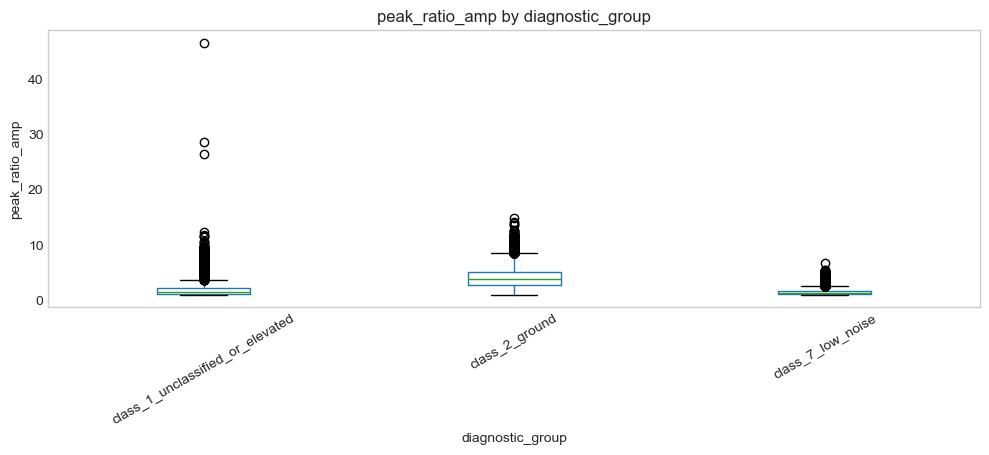

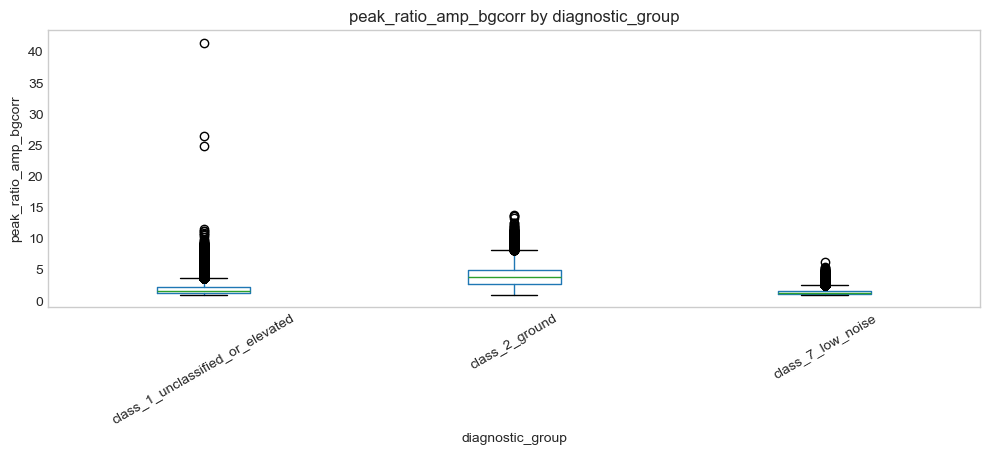

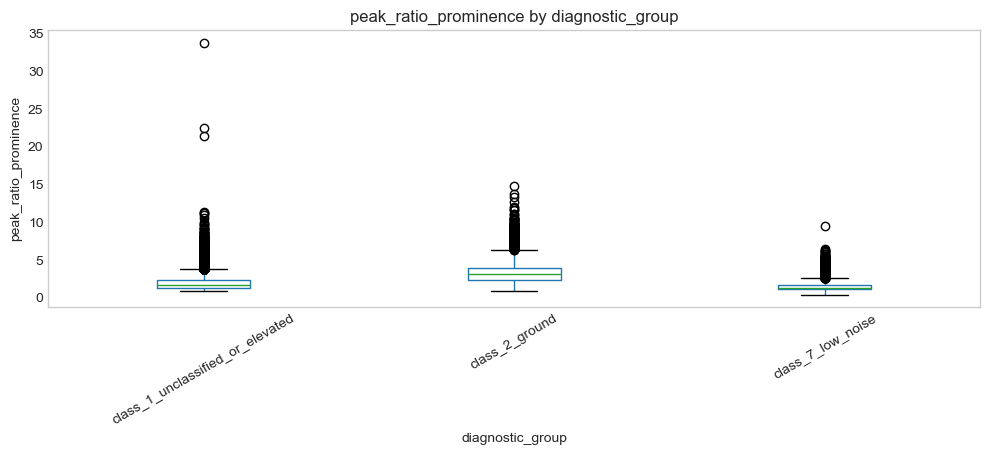

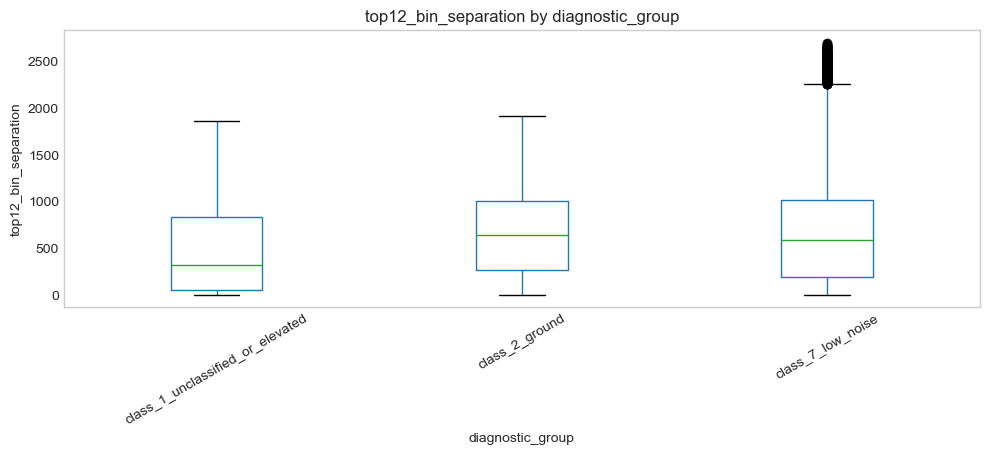

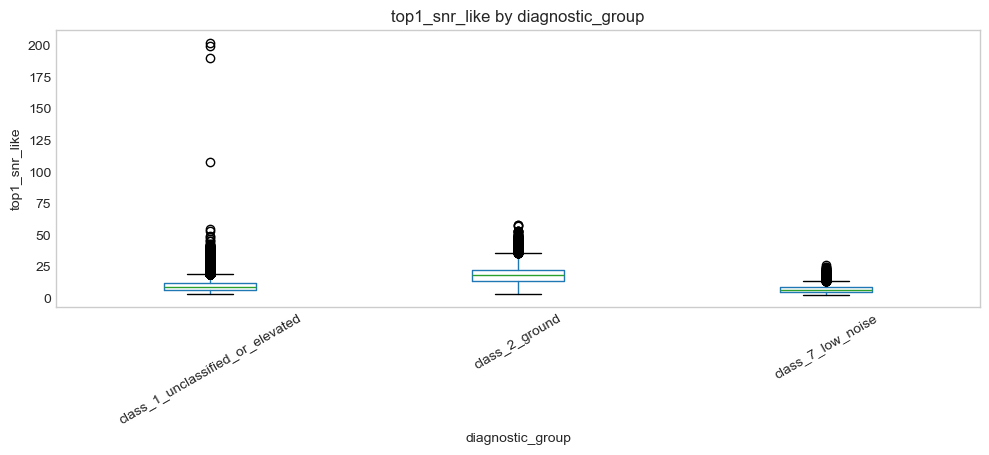

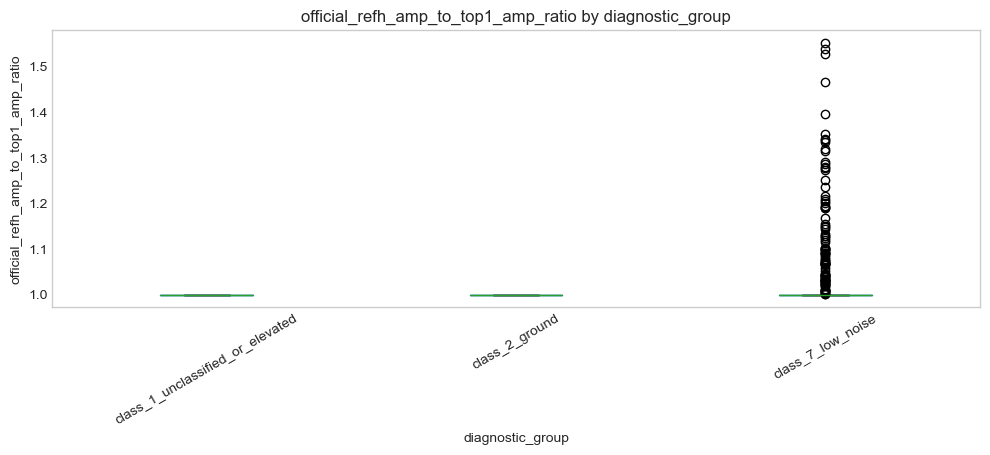

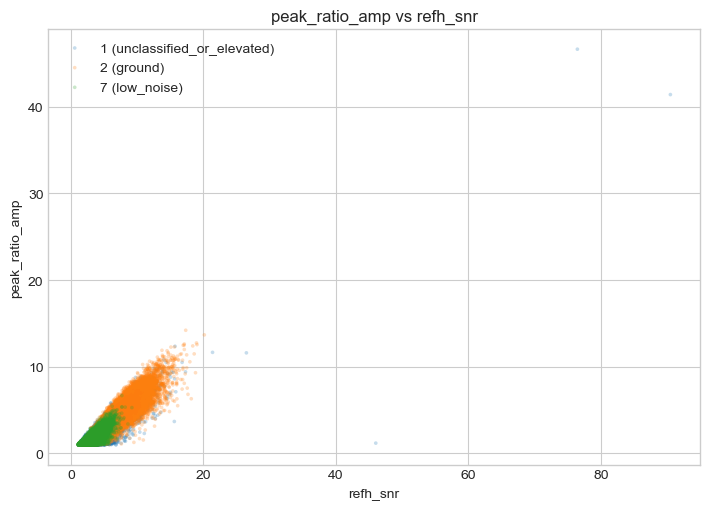

In [8]:

# --------------------------------------------------------------------------------------
# Waveform peak-ratio diagnostic summaries
# --------------------------------------------------------------------------------------

if ENABLE_WAVEFORM_PEAK_FEATURES and not analysis_df.empty and "waveform_feature_available" in analysis_df.columns:
    wf_plot_df = analysis_df.copy()
    wf_plot_df["waveform_feature_available"] = pd.to_numeric(wf_plot_df["waveform_feature_available"], errors="coerce").fillna(0).astype(bool)
    wf_plot_df = wf_plot_df[wf_plot_df["waveform_feature_available"]].copy()

    if wf_plot_df.empty:
        print("No waveform features are available for the current analysis subset.")
    else:
        wf_plot_df["class_label"] = wf_plot_df["classification"].map(lambda x: f"{int(x)} ({CLASS_NAME_MAP.get(int(x), 'class')})")
        group_col = "diagnostic_group" if "diagnostic_group" in wf_plot_df.columns else "class_label"

        waveform_summary_columns = [
            "n_detected_peaks",
            "peak_ratio_amp",
            "peak_ratio_amp_bgcorr",
            "peak_ratio_prominence",
            "top12_bin_separation",
            "top1_width_bins",
            "top1_snr_like",
            "official_refh_amp_to_top1_amp_ratio",
            "official_refh_amp_to_top1_bgcorr_ratio",
        ]
        waveform_summary_columns = [col for col in waveform_summary_columns if col in wf_plot_df.columns]
        print("Waveform feature summary by classification")
        display(summarize_class_tables({int(k): g for k, g in wf_plot_df.groupby("classification")}, waveform_summary_columns))

        if group_col == "diagnostic_group":
            print("Waveform feature summary by diagnostic_group")
            diagnostic_summary = []
            for group_name, group in wf_plot_df.groupby("diagnostic_group", sort=True):
                row = {"diagnostic_group": group_name, "n": int(len(group))}
                for col in waveform_summary_columns:
                    values = pd.to_numeric(group[col], errors="coerce").dropna()
                    row[f"{col}_median"] = float(values.median()) if len(values) else np.nan
                    row[f"{col}_p05"] = float(values.quantile(0.05)) if len(values) else np.nan
                    row[f"{col}_p95"] = float(values.quantile(0.95)) if len(values) else np.nan
                diagnostic_summary.append(row)
            display(pd.DataFrame(diagnostic_summary))

        features_to_plot = [
            "peak_ratio_amp",
            "peak_ratio_amp_bgcorr",
            "peak_ratio_prominence",
            "top12_bin_separation",
            "top1_snr_like",
            "official_refh_amp_to_top1_amp_ratio",
        ]
        features_to_plot = [col for col in features_to_plot if col in wf_plot_df.columns and pd.to_numeric(wf_plot_df[col], errors="coerce").notna().any()]

        for feature in features_to_plot:
            plot_df = wf_plot_df[[group_col, feature]].copy()
            plot_df[feature] = pd.to_numeric(plot_df[feature], errors="coerce")
            plot_df = plot_df.dropna()
            if plot_df.empty:
                continue
            plot_df = sample_per_group(plot_df, group_col, MAX_BOX_PER_GROUP)

            fig, ax = plt.subplots(figsize=(10, 4.8))
            plot_df.boxplot(column=feature, by=group_col, ax=ax, grid=False, rot=30)
            ax.set_title(f"{feature} by {group_col}")
            ax.set_xlabel(group_col)
            ax.set_ylabel(feature)
            fig.suptitle("")
            fig.tight_layout()
            plt.show()

        if {"peak_ratio_amp", "refh_snr", "classification"}.issubset(wf_plot_df.columns):
            scatter_df = wf_plot_df[["peak_ratio_amp", "refh_snr", "classification", group_col]].copy()
            scatter_df["peak_ratio_amp"] = pd.to_numeric(scatter_df["peak_ratio_amp"], errors="coerce")
            scatter_df["refh_snr"] = pd.to_numeric(scatter_df["refh_snr"], errors="coerce")
            scatter_df = scatter_df.dropna()
            if len(scatter_df) > MAX_SCATTER:
                scatter_df = scatter_df.sample(MAX_SCATTER, random_state=WAVEFORM_RANDOM_SEED)
            if not scatter_df.empty:
                fig, ax = plt.subplots(figsize=(7.2, 5.2))
                for class_code, group in scatter_df.groupby("classification", sort=True):
                    label = f"{int(class_code)} ({CLASS_NAME_MAP.get(int(class_code), 'class')})"
                    ax.scatter(
                        group["refh_snr"],
                        group["peak_ratio_amp"],
                        s=7,
                        alpha=0.25,
                        edgecolors="none",
                        label=label,
                    )
                ax.set_title("peak_ratio_amp vs refh_snr")
                ax.set_xlabel("refh_snr")
                ax.set_ylabel("peak_ratio_amp")
                ax.legend()
                fig.tight_layout()
                plt.show()
else:
    print("Waveform summaries are skipped because waveform diagnostics are disabled or no analysis rows are loaded.")


In [9]:
for class_code, df in raw_class_tables.items():
    class_name = CLASS_NAME_MAP.get(int(class_code), f"class_{int(class_code)}")
    print(f"class {class_code} ({class_name}): rows={len(df):,}")
    display(df.head(PREVIEW_ROWS))


class 1 (unclassified_or_elevated): rows=925,673


,x,y,z,classification,longitude,latitude,x_original_m,y_original_m,z_original_m,empirical_dz_m,quality_flag,ground_align_inlier,refh_amp,refh_snr,bg_mean,bg_std,refh_thres,good_snr,transfer_status,nearest3dep_dist_m,nearest3dep_class,dominant3dep_class,class_vote_ratio,n_3dep_neighbors,track_num,sweep_num,delta_time,refh_error,point_index,local_neighbor_count,point_density_pts_m3,roughness_m,local_z_span_m,local_z_nmad_m,local_slope_deg,sphericity,linearity,planarity,anisotropy,omnivariance,waveform_feature_available,n_detected_peaks,raw_max_bin,raw_max_amp,top1_bin,top2_bin,top1_amp,top2_amp,top1_amp_bgcorr,top2_amp_bgcorr,peak_ratio_amp,peak_ratio_amp_bgcorr,top1_prominence,top2_prominence,peak_ratio_prominence,top1_width_bins,top2_width_bins,top12_bin_separation,top1_snr_like,top2_snr_like,refh_bin,refh_to_top1_bin_delta,refh_peak_rank,official_refh_amp_to_top1_amp_ratio,official_refh_amp_to_top1_bgcorr_ratio
0,349197.355,4006563.277,4.511,1,-76.677217,36.192138,349197.354560,4.006563e+06,-33.510032,38.021481,0,0,3051.0,10.453941,-10.077966,100.643211,291.851654,1,1,0.098605,2,1,0.666667,12,24,0,2.171855e+08,0.028437,3,741.0,1.415206,0.047077,0.333,0.005930,1.861526,0.031343,0.755724,0.212933,0.968657,0.041136,1.0,11.0,1642.0,3051.0,1642.0,1593.0,3051.0,502.0,3061.077966,512.077966,6.077689,5.977758,3280.0,619.0,5.298869,7.130605,6.213392,49.0,30.415147,5.088053,NaN,NaN,NaN,1.0,0.996708
1,349195.873,4006569.334,4.555,1,-76.677235,36.192192,349195.873271,4.006569e+06,-33.466914,38.021481,0,0,2818.0,8.964285,-21.840361,112.066322,314.358612,1,1,0.038694,1,1,0.666667,12,48,0,2.171855e+08,0.028509,6,790.0,1.508789,0.036619,0.161,0.004448,2.908499,0.026417,0.714193,0.259390,0.973583,0.028957,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,349195.393,4006571.272,4.587,1,-76.677241,36.192210,349195.393008,4.006571e+06,-33.434900,38.021481,0,0,2404.0,7.594783,-18.001541,111.511536,316.533051,1,3,0.210430,2,1,0.500000,12,56,0,2.171855e+08,0.028535,7,775.0,1.480141,0.187864,0.317,0.110454,7.963670,0.072165,0.654488,0.273347,0.927835,0.038867,1.0,8.0,1642.0,2404.0,1642.0,1321.0,2404.0,651.0,2422.001542,669.001542,3.692780,3.620323,2625.0,849.0,3.091873,7.665110,6.681982,321.0,21.719740,5.999393,NaN,NaN,NaN,1.0,0.992567
3,349194.236,4006575.806,4.251,1,-76.677254,36.192250,349194.235723,4.006576e+06,-33.770744,38.021481,0,0,2612.0,8.225683,-20.634438,112.725479,317.542023,1,3,0.259787,1,1,0.583333,12,72,0,2.171855e+08,0.028601,9,761.0,1.453403,0.160826,0.308,0.109712,11.243828,0.044451,0.682806,0.272742,0.955549,0.032350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,349198.671,4006557.092,4.619,1,-76.677201,36.192082,349198.670534,4.006557e+06,-33.402222,38.021481,0,0,2342.0,7.231071,-5.882242,109.920784,323.880127,1,3,0.105355,2,1,0.583333,12,1,0,2.171855e+08,0.028385,32,258.0,0.492744,0.056525,0.161,0.016309,2.854368,0.032474,0.764419,0.203107,0.967526,0.031827,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


class 2 (ground): rows=2,143,347


,x,y,z,classification,longitude,latitude,x_original_m,y_original_m,z_original_m,empirical_dz_m,quality_flag,ground_align_inlier,refh_amp,refh_snr,bg_mean,bg_std,refh_thres,good_snr,transfer_status,nearest3dep_dist_m,nearest3dep_class,dominant3dep_class,class_vote_ratio,n_3dep_neighbors,track_num,sweep_num,delta_time,refh_error,point_index,local_neighbor_count,point_density_pts_m3,roughness_m,local_z_span_m,local_z_nmad_m,local_slope_deg,sphericity,linearity,planarity,anisotropy,omnivariance,waveform_feature_available,n_detected_peaks,raw_max_bin,raw_max_amp,top1_bin,top2_bin,top1_amp,top2_amp,top1_amp_bgcorr,top2_amp_bgcorr,peak_ratio_amp,peak_ratio_amp_bgcorr,top1_prominence,top2_prominence,peak_ratio_prominence,top1_width_bins,top2_width_bins,top12_bin_separation,top1_snr_like,top2_snr_like,refh_bin,refh_to_top1_bin_delta,refh_peak_rank,official_refh_amp_to_top1_amp_ratio,official_refh_amp_to_top1_bgcorr_ratio
0,349198.848,4006556.801,4.623,2,-76.677199,36.192080,349198.848317,4.006557e+06,-33.398180,38.021481,0,0,1972.0,6.681900,-18.115089,104.413582,295.125641,1,3,0.145213,2,2,0.583333,12,0,0,2.171855e+08,0.028377,0,229.0,0.437358,0.055006,0.161,0.016309,2.854368,0.032474,0.764419,0.203107,0.967526,0.031827,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,349198.418,4006558.801,4.491,2,-76.677205,36.192098,349198.418245,4.006559e+06,-33.530279,38.021481,0,1,1688.0,6.515464,-41.232136,100.102684,259.075928,1,1,0.160596,1,2,0.916667,12,8,0,2.171855e+08,0.028393,1,387.0,0.739116,0.024424,0.172,0.006672,1.312743,0.013540,0.795932,0.190528,0.986460,0.026357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,349197.881,4006560.570,4.389,2,-76.677211,36.192114,349197.880555,4.006561e+06,-33.632640,38.021481,6,0,978.0,3.884341,-35.616867,95.799011,251.780167,0,1,0.149502,2,2,0.750000,12,16,0,2.171855e+08,0.028417,2,556.0,1.061882,0.051499,0.429,0.022980,7.719473,0.053694,0.717425,0.228882,0.946306,0.032180,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,349196.783,4006565.274,4.524,2,-76.677224,36.192156,349196.782506,4.006565e+06,-33.497252,38.021481,0,0,2505.0,8.848446,-45.726994,109.609184,283.100555,1,1,0.102149,1,2,0.833333,12,32,0,2.171855e+08,0.028465,4,752.0,1.436214,0.007237,0.301,0.004448,3.421130,0.039729,0.679511,0.280760,0.960271,0.030989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,349196.303,4006567.247,4.547,2,-76.677230,36.192174,349196.303318,4.006567e+06,-33.474502,38.021481,0,1,2214.0,7.255413,4.661666,100.163269,305.151459,1,3,0.170879,2,2,0.583333,12,40,0,2.171855e+08,0.028488,5,742.0,1.417116,0.024275,0.303,0.008154,4.718907,0.044010,0.687759,0.268232,0.955990,0.035242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


class 7 (low_noise): rows=535,460


,x,y,z,classification,longitude,latitude,x_original_m,y_original_m,z_original_m,empirical_dz_m,quality_flag,ground_align_inlier,refh_amp,refh_snr,bg_mean,bg_std,refh_thres,good_snr,transfer_status,nearest3dep_dist_m,nearest3dep_class,dominant3dep_class,class_vote_ratio,n_3dep_neighbors,track_num,sweep_num,delta_time,refh_error,point_index,local_neighbor_count,point_density_pts_m3,roughness_m,local_z_span_m,local_z_nmad_m,local_slope_deg,sphericity,linearity,planarity,anisotropy,omnivariance,waveform_feature_available,n_detected_peaks,raw_max_bin,raw_max_amp,top1_bin,top2_bin,top1_amp,top2_amp,top1_amp_bgcorr,top2_amp_bgcorr,peak_ratio_amp,peak_ratio_amp_bgcorr,top1_prominence,top2_prominence,peak_ratio_prominence,top1_width_bins,top2_width_bins,top12_bin_separation,top1_snr_like,top2_snr_like,refh_bin,refh_to_top1_bin_delta,refh_peak_rank,official_refh_amp_to_top1_amp_ratio,official_refh_amp_to_top1_bgcorr_ratio
0,349197.224,4006584.333,125.498,7,-76.677223,36.192328,349197.223977,4.006584e+06,87.476162,38.021481,6,0,536.0,1.920310,-50.805878,109.975830,279.121613,0,0,inf,7,1,0.0,0,106,0,2.171855e+08,0.028428,77,1.0,0.00191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,349180.935,4006607.122,-136.984,7,-76.677408,36.192531,349180.935250,4.006607e+06,-175.005561,38.021481,6,0,440.0,1.520084,-48.988979,112.815529,289.457611,0,0,inf,7,1,0.0,0,187,0,2.171855e+08,0.029534,119,1.0,0.00191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,349194.654,4006560.845,-68.831,7,-76.677247,36.192116,349194.653624,4.006561e+06,-106.852420,38.021481,6,0,628.0,1.975680,-8.317426,108.727554,317.865234,0,0,inf,7,1,0.0,0,17,1,2.171855e+08,0.028599,290,1.0,0.00191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,349194.919,4006584.572,74.293,7,-76.677248,36.192330,349194.919447,4.006585e+06,36.271979,38.021481,6,0,671.0,2.234454,-29.732943,110.010002,300.297058,0,0,inf,7,1,0.0,0,106,1,2.171855e+08,0.028558,333,1.0,0.00191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,349201.513,4006584.844,237.805,7,-76.677175,36.192333,349201.512920,4.006585e+06,199.783453,38.021481,6,0,475.0,1.623387,-57.096081,116.564713,292.598053,0,0,inf,7,1,0.0,0,107,1,2.171855e+08,0.028165,365,1.0,0.00191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
if PRODUCT_KIND == "extract_refh_ground" and not analysis_df.empty:
    plot_df = analysis_df.loc[pd.to_numeric(analysis_df["dtm_sample_valid"], errors="coerce").fillna(0).astype(bool)].copy()
    plot_df["class_label"] = plot_df["classification"].map(lambda x: CLASS_NAME_MAP.get(int(x), f"class_{int(x)}"))

    if plot_df.empty:
        print("No valid DTM samples were found in the analysis subset.")
    else:
        fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

        for class_code, group in plot_df.groupby("classification", sort=True):
            label = f"{class_code} ({CLASS_NAME_MAP.get(int(class_code), 'class')})"
            axes[0].hist(
                pd.to_numeric(group["height_above_ground_m"], errors="coerce").dropna(),
                bins=80,
                alpha=0.45,
                label=label,
            )
        axes[0].set_title("height_above_ground_m histogram")
        axes[0].set_xlabel("meters")
        axes[0].set_ylabel("count")
        axes[0].legend()

        box_df = plot_df[["class_label", "height_above_ground_m"]].dropna()
        box_df = sample_per_group(box_df, "class_label", MAX_BOX_PER_GROUP)
        box_df.boxplot(column="height_above_ground_m", by="class_label", ax=axes[1], grid=False)
        axes[1].set_title("height_above_ground_m by class")
        axes[1].set_xlabel("class")
        axes[1].set_ylabel("meters")

        scatter_df = plot_df[["ground_resid", "height_above_ground_m", "classification"]].dropna()
        if len(scatter_df) > MAX_SCATTER:
            scatter_df = scatter_df.sample(MAX_SCATTER, random_state=42)
        for class_code, group in scatter_df.groupby("classification", sort=True):
            label = f"{class_code} ({CLASS_NAME_MAP.get(int(class_code), 'class')})"
            axes[2].scatter(
                group["ground_resid"],
                group["height_above_ground_m"],
                s=5,
                alpha=0.20,
                edgecolors="none",
                label=label,
            )
        axes[2].set_title("ground_resid vs height_above_ground_m")
        axes[2].set_xlabel("ground_resid (z - preliminary ground)")
        axes[2].set_ylabel("height_above_ground_m")
        axes[2].legend()

        fig.suptitle("")
        fig.tight_layout()
else:
    print("Height-above-ground plots are only produced for PRODUCT_KIND='extract_refh_ground'.")


Height-above-ground plots are only produced for PRODUCT_KIND='extract_refh_ground'.


In [11]:
interactive_3d_class_tables = {class_code: df.copy() for class_code, df in analysis_class_tables.items()}
if INTERACTIVE_3D_INCLUDE_NOISE and 7 in raw_class_tables and 7 not in interactive_3d_class_tables:
    interactive_3d_class_tables[7] = raw_class_tables[7].copy()

interactive_3d_source_df = combine_class_tables(interactive_3d_class_tables)
interactive_3d_numeric_columns = get_numeric_axis_candidates(interactive_3d_source_df)
interactive_3d_default_axes = None
interactive_3d_hover_columns = []
interactive_3d_class_colors = class_color_lookup(sorted(interactive_3d_class_tables))

if ENABLE_INTERACTIVE_3D and not interactive_3d_source_df.empty and interactive_3d_numeric_columns:
    interactive_3d_default_axes = resolve_default_3d_axes(PRODUCT_KIND, interactive_3d_numeric_columns)
    interactive_3d_hover_columns = get_hover_columns(interactive_3d_source_df, interactive_3d_default_axes)
    print("interactive_3d_classes:", sorted(interactive_3d_class_tables))
    print("interactive_3d_numeric_columns:", interactive_3d_numeric_columns)
    print("interactive_3d_default_axes:", interactive_3d_default_axes)
else:
    print("Interactive 3D view is disabled or no numeric analysis columns are available.")


interactive_3d_classes: [1, 2, 7]
interactive_3d_numeric_columns: ['x', 'y', 'z', 'classification', 'longitude', 'latitude', 'x_original_m', 'y_original_m', 'z_original_m', 'empirical_dz_m', 'quality_flag', 'ground_align_inlier', 'refh_amp', 'refh_snr', 'bg_mean', 'bg_std', 'refh_thres', 'good_snr', 'transfer_status', 'nearest3dep_dist_m', 'nearest3dep_class', 'dominant3dep_class', 'class_vote_ratio', 'n_3dep_neighbors', 'track_num', 'sweep_num', 'delta_time', 'refh_error', 'point_index', 'local_neighbor_count', 'point_density_pts_m3', 'roughness_m', 'local_z_span_m', 'local_z_nmad_m', 'local_slope_deg', 'sphericity', 'linearity', 'planarity', 'anisotropy', 'omnivariance', 'waveform_feature_available', 'n_detected_peaks', 'raw_max_bin', 'raw_max_amp', 'top1_bin', 'top2_bin', 'top1_amp', 'top2_amp', 'top1_amp_bgcorr', 'top2_amp_bgcorr', 'peak_ratio_amp', 'peak_ratio_amp_bgcorr', 'top1_prominence', 'top2_prominence', 'peak_ratio_prominence', 'top1_width_bins', 'top2_width_bins', 'top12_b

In [ ]:
if ENABLE_INTERACTIVE_3D and interactive_3d_default_axes is not None:
    x_default, y_default, z_default = interactive_3d_default_axes
    x_axis_widget = widgets.Dropdown(options=interactive_3d_numeric_columns, value=x_default, description="X axis")
    y_axis_widget = widgets.Dropdown(options=interactive_3d_numeric_columns, value=y_default, description="Y axis")
    z_axis_widget = widgets.Dropdown(options=interactive_3d_numeric_columns, value=z_default, description="Z axis")

    x_min_widget = widgets.Text(value="", placeholder="auto", description="X min")
    x_max_widget = widgets.Text(value="", placeholder="auto", description="X max")
    y_min_widget = widgets.Text(value="", placeholder="auto", description="Y min")
    y_max_widget = widgets.Text(value="", placeholder="auto", description="Y max")
    z_min_widget = widgets.Text(value="", placeholder="auto", description="Z min")
    z_max_widget = widgets.Text(value="", placeholder="auto", description="Z max")

    def parse_axis_limit(text_value: str) -> float | None:
        text = str(text_value).strip()
        if not text:
            return None
        return float(text)

    def apply_axis_range(frame: pd.DataFrame, axis_field: str, axis_config: dict[str, object], min_text: str, max_text: str) -> None:
        min_val = parse_axis_limit(min_text)
        max_val = parse_axis_limit(max_text)
        if min_val is None and max_val is None:
            return

        axis_values = pd.to_numeric(frame[axis_field], errors="coerce").to_numpy(dtype=np.float64)
        finite = np.isfinite(axis_values)
        if not np.any(finite):
            return

        auto_min = float(np.nanmin(axis_values[finite]))
        auto_max = float(np.nanmax(axis_values[finite]))
        lo = auto_min if min_val is None else float(min_val)
        hi = auto_max if max_val is None else float(max_val)
        if not np.isfinite(lo) or not np.isfinite(hi) or lo >= hi:
            return

        axis_config["autorange"] = False
        axis_config["range"] = [lo, hi]

    def render_interactive_3d(
        x_axis: str,
        y_axis: str,
        z_axis: str,
        x_min_text: str,
        x_max_text: str,
        y_min_text: str,
        y_max_text: str,
        z_min_text: str,
        z_max_text: str,
    ) -> None:
        frame = prepare_interactive_3d_frame(
            interactive_3d_source_df,
            x_axis=x_axis,
            y_axis=y_axis,
            z_axis=z_axis,
            product_kind=PRODUCT_KIND,
            exclude_invalid_3d_points=EXCLUDE_INVALID_3D_POINTS,
        )
        frame = stratified_sample_for_3d(
            frame,
            max_points_per_class=MAX_3D_POINTS_PER_CLASS,
            max_points_total=MAX_3D_POINTS_TOTAL,
        )
        hover_columns = get_hover_columns(frame, (x_axis, y_axis, z_axis))
        fig = make_interactive_3d_figure(
            frame,
            x_axis=x_axis,
            y_axis=y_axis,
            z_axis=z_axis,
            hover_columns=hover_columns,
            class_colors=interactive_3d_class_colors,
        )

        if not frame.empty:
            scene = {
                "xaxis": {"title": x_axis, "autorange": True},
                "yaxis": {"title": y_axis, "autorange": True},
                "zaxis": {"title": z_axis, "autorange": True},
                "aspectmode": "cube",
            }
            apply_axis_range(frame, x_axis, scene["xaxis"], x_min_text, x_max_text)
            apply_axis_range(frame, y_axis, scene["yaxis"], y_min_text, y_max_text)
            apply_axis_range(frame, z_axis, scene["zaxis"], z_min_text, z_max_text)
            fig.update_layout(scene=scene)

        fig.show()

    axis_controls = widgets.HBox([x_axis_widget, y_axis_widget, z_axis_widget])
    x_range_controls = widgets.HBox([x_min_widget, x_max_widget])
    y_range_controls = widgets.HBox([y_min_widget, y_max_widget])
    z_range_controls = widgets.HBox([z_min_widget, z_max_widget])
    controls = widgets.VBox([axis_controls, x_range_controls, y_range_controls, z_range_controls])
    output = widgets.interactive_output(
        render_interactive_3d,
        {
            "x_axis": x_axis_widget,
            "y_axis": y_axis_widget,
            "z_axis": z_axis_widget,
            "x_min_text": x_min_widget,
            "x_max_text": x_max_widget,
            "y_min_text": y_min_widget,
            "y_max_text": y_max_widget,
            "z_min_text": z_min_widget,
            "z_max_text": z_max_widget,
        },
    )
    display(controls, output)
else:
    print("Interactive 3D view is unavailable for the current analysis subset.")


Output()

In [13]:
if EXPORT_CLASS_CSV:
    export_root = product_paths["export_root"] / point_cloud_path.stem
    exported_paths = export_class_tables(raw_class_tables, export_root)
    export_table = pd.DataFrame(
        {
            "classification": list(exported_paths.keys()),
            "csv_path": [str(path.resolve()) for path in exported_paths.values()],
        }
    ).sort_values("classification").reset_index(drop=True)
    display(export_table)
else:
    print("Set EXPORT_CLASS_CSV = True to write one CSV per class.")


Set EXPORT_CLASS_CSV = True to write one CSV per class.


## Results

- `raw_class_tables[class_code]` holds the per-point table for each loaded LAS/LAZ class.
- `analysis_class_tables` and `analysis_df` include local geometry features and, when enabled, joined H5 waveform peak diagnostics.
- `waveform_features_df` stores one row per sampled H5 point index with peak-ratio diagnostics.
- `peak_ratio_amp` and related fields are diagnostic features only. They are not used here to change LAS classification.
- Use `diagnostic_group` when `eval_gt_class` exists to compare correct and error subsets such as `true7_pred1`, `true1_pred2`, and `true2_pred7`.


## Next steps

- Inspect whether `true7_pred1` differs from `correct_processed` in `top1_snr_like`, `peak_ratio_amp`, `peak_ratio_prominence`, `top12_bin_separation`, or `official_refh_amp_to_top1_amp_ratio`.
- If waveform features are strongly separable and ground-related error subsets remain stable, migrate only conservative rules into `classify_and_evaluate_casals_refh.py`.
- Do not use `peak_ratio_amp < threshold` alone as a noise filter; low peak dominance may represent real multi-return structure.
- If H5 alignment reports large lon/lat deltas, stop and fix point-index alignment before interpreting waveform diagnostics.
